# Project 1 (5-class): Esgario-style labels, Mixed dropped

**Not the official artefact.** The graded 6-class run is `P1_notebook.ipynb`.

This notebook drops `predominant_stress == 5` (Mixed) **before** the split: **1,685** images, five classes (Healthy, Miner, Rust, Phoma, Cercospora). Feature caches and result/figure tags use `_nomix` so 6-class files are not overwritten.

**Comparison target:** Esgario et al. (2020) leaf ResNet50 **95.63%** accuracy on 1,685 images, 70/15/15, HSV-S crop. We still use a random stratified split and a simpler HSV-S crop (no specialist lesion crops), so a remaining gap is expected.


## 1. Setup and imports

Use the **WSL** kernel so EfficientNet / ResNet see the RTX 4070 (CUDA). In Cursor: kernel picker → *Select Another Kernel* → *Python Environments* → `/home/alecs/pml_venv/bin/python` (display name **Python (PML WSL GPU)** if registered). The Windows `.venv` is CPU-only TensorFlow.


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from p1_core import (
    RANDOM_STATE, STRESS_NAMES, BRACOL_CLASSES, BRACOL_TO_STRESS,
    resolve_paths, save_and_show, report_compute,
    LeafDataset, TrainValTestSplit,
    HandcraftedFeatures, FrozenDeepFeatures, PCAFeatures, scale_pack,
    SVMPipeline, XGBoostPipeline, EfficientNetPipeline, ResNetPipeline,
    load_bracol_labels, ensemble_average, classification_metrics,
    target_names_for,
)

rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PATHS = resolve_paths()
TAG = "_nomix"
print("Data:", PATHS["data_dir"])
print("Figures:", PATHS["figures_dir"])
print("CSV exists:", os.path.isfile(PATHS["csv_path"]))
print("Image folder exists:", os.path.isdir(PATHS["image_dir"]))
print("Protocol: 5-class, drop Mixed, tag", TAG)
report_compute()


Data: /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-datasets/leaf
Figures: /mnt/c/Users/Alecs/PML/Project_1/figures
CSV exists: True
Image folder exists: True
Protocol: 5-class, drop Mixed, tag _nomix


2026-08-28 20:10:54.692726: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-28 20:10:55.175163: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-08-28 20:10:57.205594: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0 | CUDA build: True
Using GPU: ['/physical_device:GPU:0']


{'tf': '2.20.0', 'cuda_built': True, 'gpu_names': ['/physical_device:GPU:0']}

## 2. Dataset corridor — drop Mixed (class 5)

CSV has 1,747 rows. After dropping Mixed we keep **1,685** images and five labels, matching Esgario's leaf classification count (they dropped 62 mixed-equal leaves).


In [2]:
dataset = LeafDataset(PATHS["csv_path"], PATHS["image_dir"], drop_mixed=True)
df = dataset.load_and_match()
summary = dataset.eda_summary()
print(json.dumps({k: v for k, v in summary.items() if k != "class_counts"}, indent=2))
print("Class counts:", summary["class_counts"])
print("n_kept (expect 1685):", summary["n_kept"])
print(df.head())
assert 5 not in set(df["predominant_stress"].unique())


{
  "n_csv": 1747,
  "n_kept": 1685,
  "drop_mixed": true
}
Class counts: {0: 272, 1: 387, 2: 531, 3: 348, 4: 147}
n_kept (expect 1685): 1685
   id  predominant_stress  miner  rust  phoma  cercospora  severity  \
0   1                   0      0     0      0           0         0   
1   2                   0      0     0      0           0         0   
2   3                   0      0     0      0           0         0   
3   4                   0      0     0      0           0         0   
4   5                   0      0     0      0           0         0   

                                          image_path  
0  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
1  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
2  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
3  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
4  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  


## 3. Exploratory plots


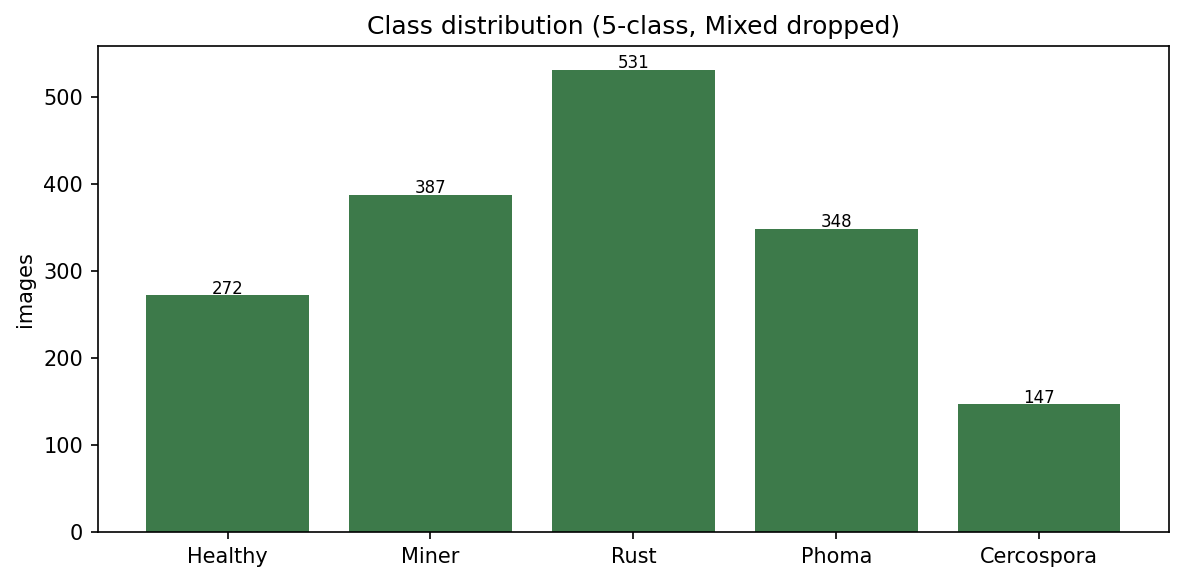

Saved class_distribution_nomix.png


In [3]:
counts = dataset.class_counts()
fig, ax = plt.subplots(figsize=(8, 4))
names = [STRESS_NAMES.get(int(i), str(i)) for i in counts.index]
ax.bar(names, counts.values, color="#3d7a4a")
ax.set_ylabel("images")
ax.set_title("Class distribution (5-class, Mixed dropped)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(int(v)), ha="center", fontsize=8)
fig.tight_layout()
save_and_show(fig, "class_distribution_nomix.png", PATHS["figures_dir"])
print("Saved class_distribution_nomix.png")


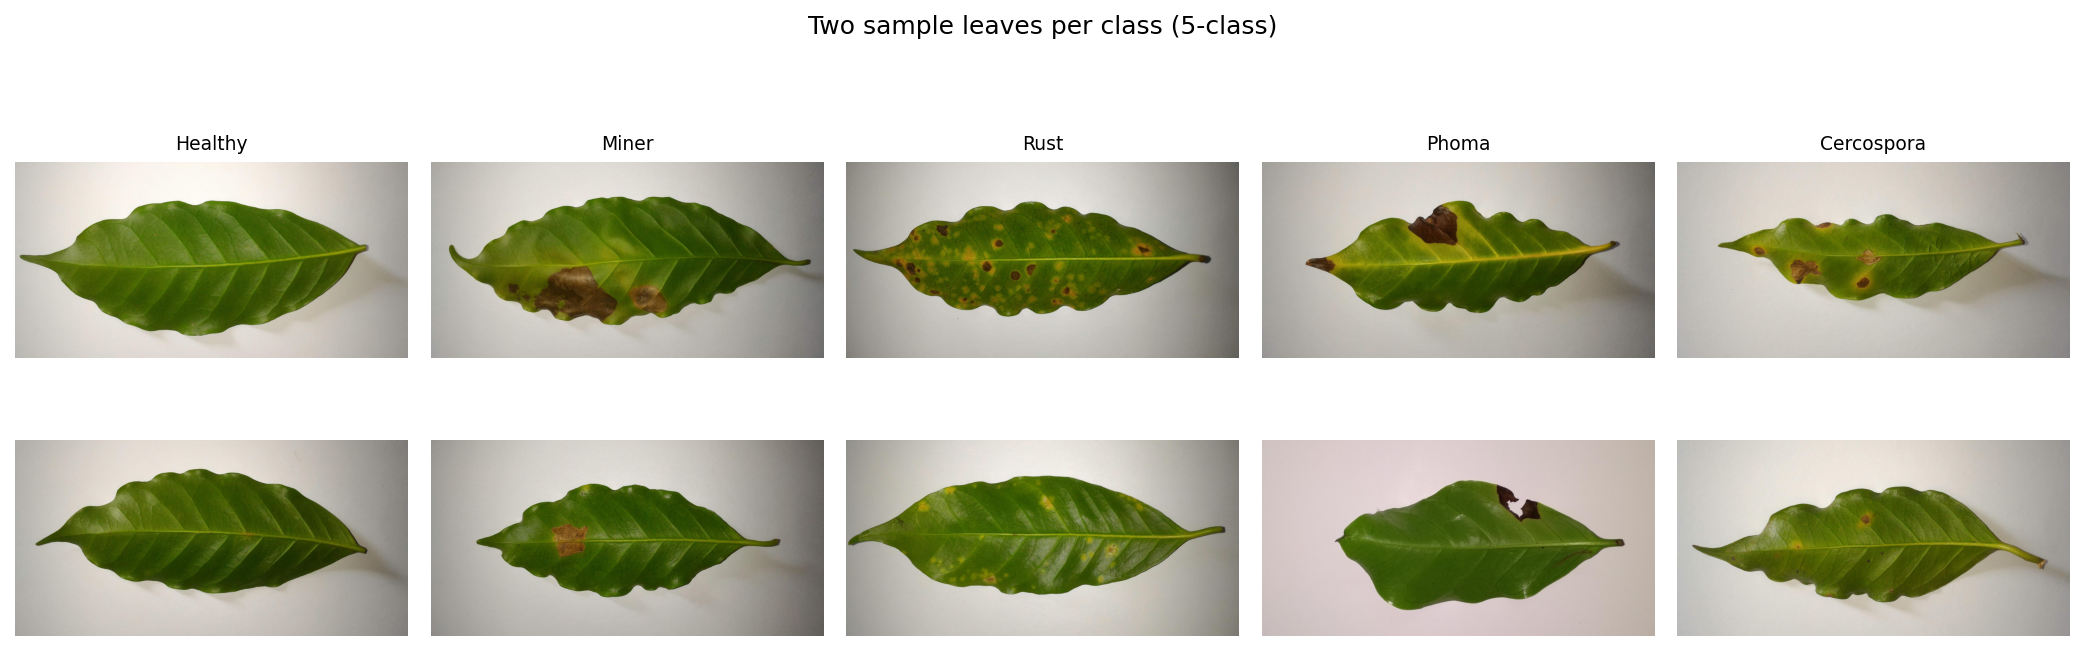

'/mnt/c/Users/Alecs/PML/Project_1/figures/sample_images_nomix.png'

In [4]:
labels = sorted(df["predominant_stress"].unique())
fig, axes = plt.subplots(2, len(labels), figsize=(14, 5))
for col, label in enumerate(labels):
    sub = df[df["predominant_stress"] == label]
    for row in range(2):
        ax = axes[row, col]
        sample = sub.iloc[row % len(sub)]
        img = plt.imread(sample["image_path"])
        ax.imshow(img)
        ax.axis("off")
        if row == 0:
            ax.set_title(STRESS_NAMES.get(int(label), str(label)), fontsize=9)
fig.suptitle("Two sample leaves per class (5-class)")
fig.tight_layout()
save_and_show(fig, "sample_images_nomix.png", PATHS["figures_dir"])


In [5]:
from PIL import Image as PILImage

with PILImage.open(df["image_path"].iloc[0]) as im:
    w, h = im.size
print(f"Native size: {w} x {h}. All current leaf JPEGs share this size; the models resize to 224 x 224.")


Native size: 2048 x 1024. All current leaf JPEGs share this size; the models resize to 224 x 224.


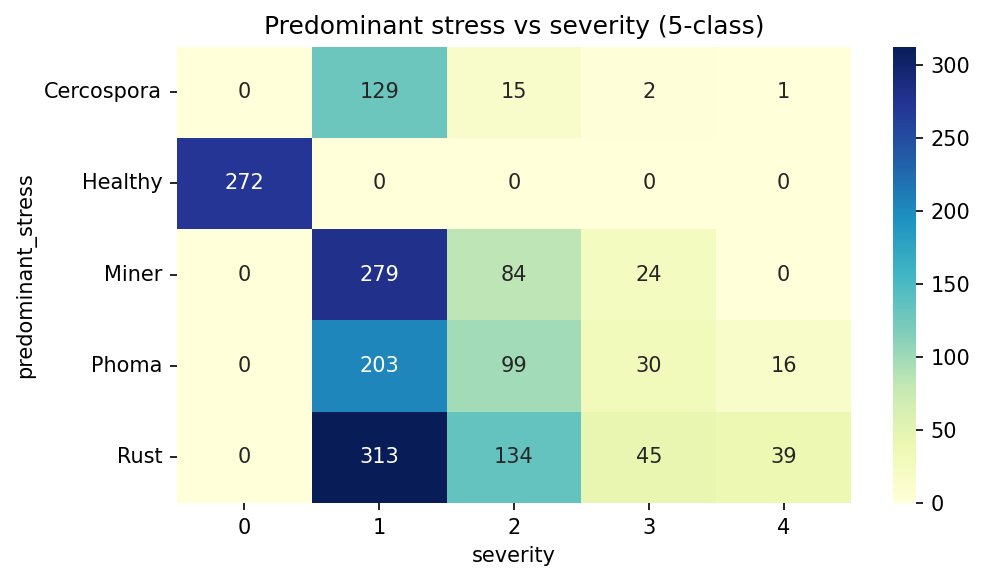

'/mnt/c/Users/Alecs/PML/Project_1/figures/eda_heatmaps_nomix.png'

In [6]:
ct = pd.crosstab(df["predominant_stress"].map(STRESS_NAMES), df["severity"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Predominant stress vs severity (5-class)")
fig.tight_layout()
save_and_show(fig, "eda_heatmaps_nomix.png", PATHS["figures_dir"])


A perceptual-hash scan on the current leaf files found no duplicate groups, so that check is omitted from the run.


## 4. Train / validation / test split (criterion h)

Stratified 70 / 15 / 15. The same indices are saved and reused by every model. Hyperparameters are chosen on validation only. Test is used once, after the config is locked.


In [7]:
split_path = os.path.join(PATHS["features_dir"], "split_ids_nomix.npz")
hc_name, deep_name = "handcrafted_nomix.npz", "frozen_deep_nomix.npz"
split = None
if os.path.exists(split_path):
    split = TrainValTestSplit.load(split_path)
    n_split = len(split.train_idx) + len(split.val_idx) + len(split.test_idx)
    if n_split != len(dataset.frame):
        print(f"Split has {n_split} rows, dataset has {len(dataset.frame)}; rebuilding.")
        os.remove(split_path)
        split = None
        for fname in (hc_name, deep_name):
            p = os.path.join(PATHS["features_dir"], fname)
            if os.path.isfile(p):
                os.remove(p)
                print("Deleted stale feature cache:", p)
if split is None:
    split = TrainValTestSplit.make(dataset, seed=RANDOM_STATE, path=split_path)
split.assert_disjoint()
print("Sizes:", split.sizes())

for name, idx in [("train", split.train_idx), ("val", split.val_idx), ("test", split.test_idx)]:
    dist = df.iloc[idx]["predominant_stress"].value_counts(normalize=True).sort_index()
    print(name, {STRESS_NAMES[int(k)]: round(float(v), 3) for k, v in dist.items()})


Sizes: {'train': 1179, 'val': 253, 'test': 253}
train {'Healthy': 0.161, 'Miner': 0.23, 'Rust': 0.315, 'Phoma': 0.207, 'Cercospora': 0.087}
val {'Healthy': 0.162, 'Miner': 0.229, 'Rust': 0.316, 'Phoma': 0.206, 'Cercospora': 0.087}
test {'Healthy': 0.162, 'Miner': 0.229, 'Rust': 0.316, 'Phoma': 0.206, 'Cercospora': 0.087}


## 5. FE1 — Handcrafted features (criterion c)

White-background mask, then HSV histogram (512), uniform LBP (26), HOG on 224×224 with 16×16 cells. Concatenate and L2-normalise. Cache to disk.


In [8]:
hc_path = os.path.join(PATHS["features_dir"], "handcrafted_nomix.npz")
fe1 = HandcraftedFeatures(hc_path, image_size=224)
pack_hc = fe1.extract(dataset, split)
print("Handcrafted shapes:", pack_hc.X_train.shape, pack_hc.X_val.shape, pack_hc.X_test.shape)


Handcrafted shapes: (1179, 6622) (253, 6622) (253, 6622)


## 6. FE2 — Frozen EfficientNet embeddings (criterion c)

ImageNet EfficientNet-B0 without the classifier, global average pooling, 1280 numbers per image. No augmentation at extract time.


In [9]:
deep_path = os.path.join(PATHS["features_dir"], "frozen_deep_nomix.npz")
fe2 = FrozenDeepFeatures(deep_path, input_size=224, batch_size=32)
pack_deep = fe2.extract(dataset, split)
print("Deep shapes:", pack_deep.X_train.shape, pack_deep.X_val.shape, pack_deep.X_test.shape)


I0000 00:00:1787937123.393518 1435163 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:65:00.0, compute capability: 8.9


2026-08-28 20:12:06.554904: I external/local_xla/xla/service/service.cc:163] XLA service 0x70a89c001c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-28 20:12:06.554947: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-08-28 20:12:06.635745: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-08-28 20:12:07.063397: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


2026-08-28 20:12:15.461620: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-28 20:12:15.661052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-28 20:12:15.867044: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-28 20:12:16.057285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...

2026-08-28 20:13:19.426996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-28 20:13:20.096691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-28 20:13:20.324464: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-28 20:13:20.547321: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Deep shapes: (1179, 1280) (253, 1280) (253, 1280)


## 7. FE3 — PCA on frozen embeddings (optional SVM axis)

PCA is fit on the **train** embeddings only, then applied to val and test.


In [10]:
fe3 = PCAFeatures(n_components=256, source=pack_deep)
pack_pca = fe3.extract(dataset, split)
print("PCA shapes:", pack_pca.X_train.shape, "explained variance ratio sum:",
      float(fe3.pca.explained_variance_ratio_.sum()))


PCA shapes: (1179, 256) explained variance ratio sum: 0.9621226191520691


## 8. Model 1 — SVM, full grading loop

Personalized ingest: `StandardScaler` on train only. Then fit a default RBF SVM, search C × gamma on **validation** accuracy (plus a linear kernel sweep), refit the winner, report test once.

We run the loop twice: handcrafted features, then frozen deep features.


In [11]:
# One row per (model, features). A list would duplicate if you re-run a pipeline cell.
# A set of dicts is not possible (dicts are unhashable); a dict keyed by that pair upserts.
results_by_key = {}

def record(model_name, features, pipe=None, **extra):
    if pipe is not None:
        row = {
            "model": model_name,
            "features": features,
            "val_acc": pipe.val_metrics.get("acc"),
            "test_acc": pipe.test_metrics.get("acc"),
            "macro_f1": pipe.test_metrics.get("macro_f1"),
            "best_params": pipe.best_params,
        }
    else:
        row = {"model": model_name, "features": features}
        row.update(extra)
    results_by_key[(model_name, features)] = row
    print(row)

def results_rows():
    return list(results_by_key.values())


[svm_handcrafted_nomix] start  train=1179 x 6622  search=4 RBF + 4 linear  proba=False


[svm_handcrafted_nomix] ingest  scaling 1179 x 6622  elapsed 0:00


[svm_handcrafted_nomix] ingest  done in 0:00  elapsed 0:00


[svm_handcrafted_nomix] fit  skipped (default RBF is a search point)  elapsed 0:00


[svm_handcrafted_nomix] search  8 configs  elapsed 0:00


...

[svm_handcrafted_nomix] search  5/8  rbf C=0.1 gamma=scale  val_acc=0.304  0:04  remaining ~0:08  elapsed 0:14


[svm_handcrafted_nomix] search  6/8  rbf C=1 gamma=scale  val_acc=0.676  0:04  remaining ~0:06  elapsed 0:18


[svm_handcrafted_nomix] search  7/8  rbf C=10 gamma=scale  val_acc=0.704  0:04  remaining ~0:03  elapsed 0:22


[svm_handcrafted_nomix] search  8/8  rbf C=100 gamma=scale  val_acc=0.704  0:04  remaining ~0:00  elapsed 0:26


[svm_handcrafted_nomix] search  done  best={'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}  val_acc=0.704  elapsed 0:26


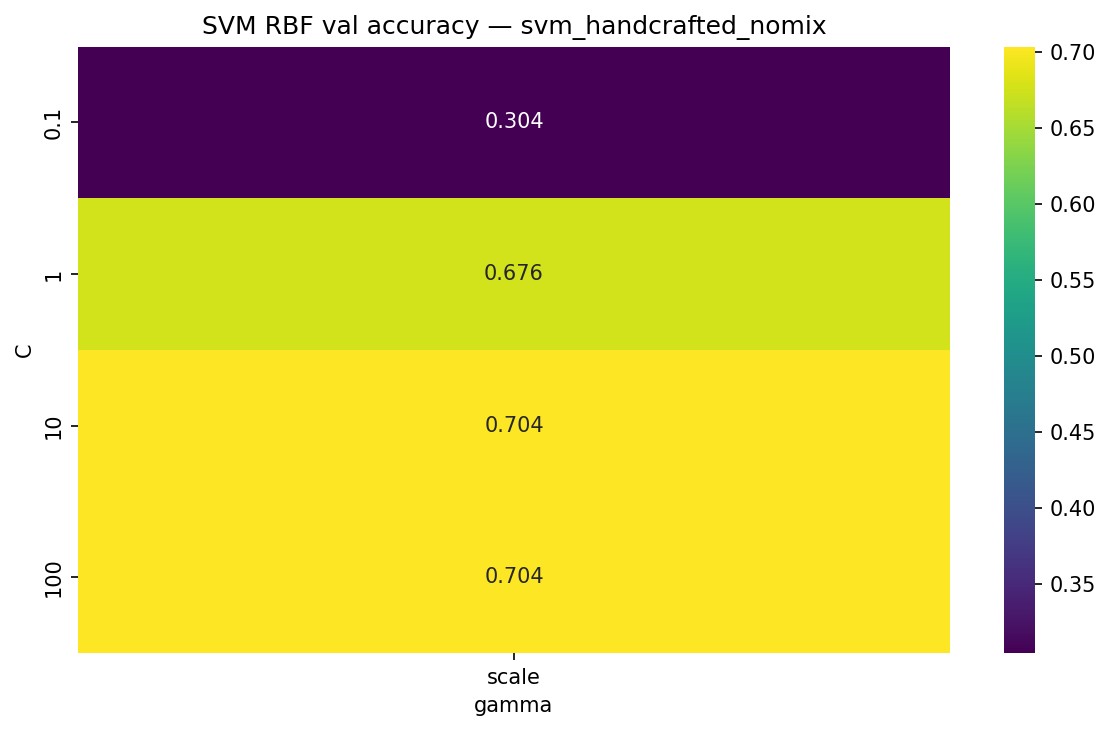

[svm_handcrafted_nomix] refit  rbf C=10 gamma=scale  proba=False  elapsed 0:26


[svm_handcrafted_nomix] refit  done in 0:05  elapsed 0:31


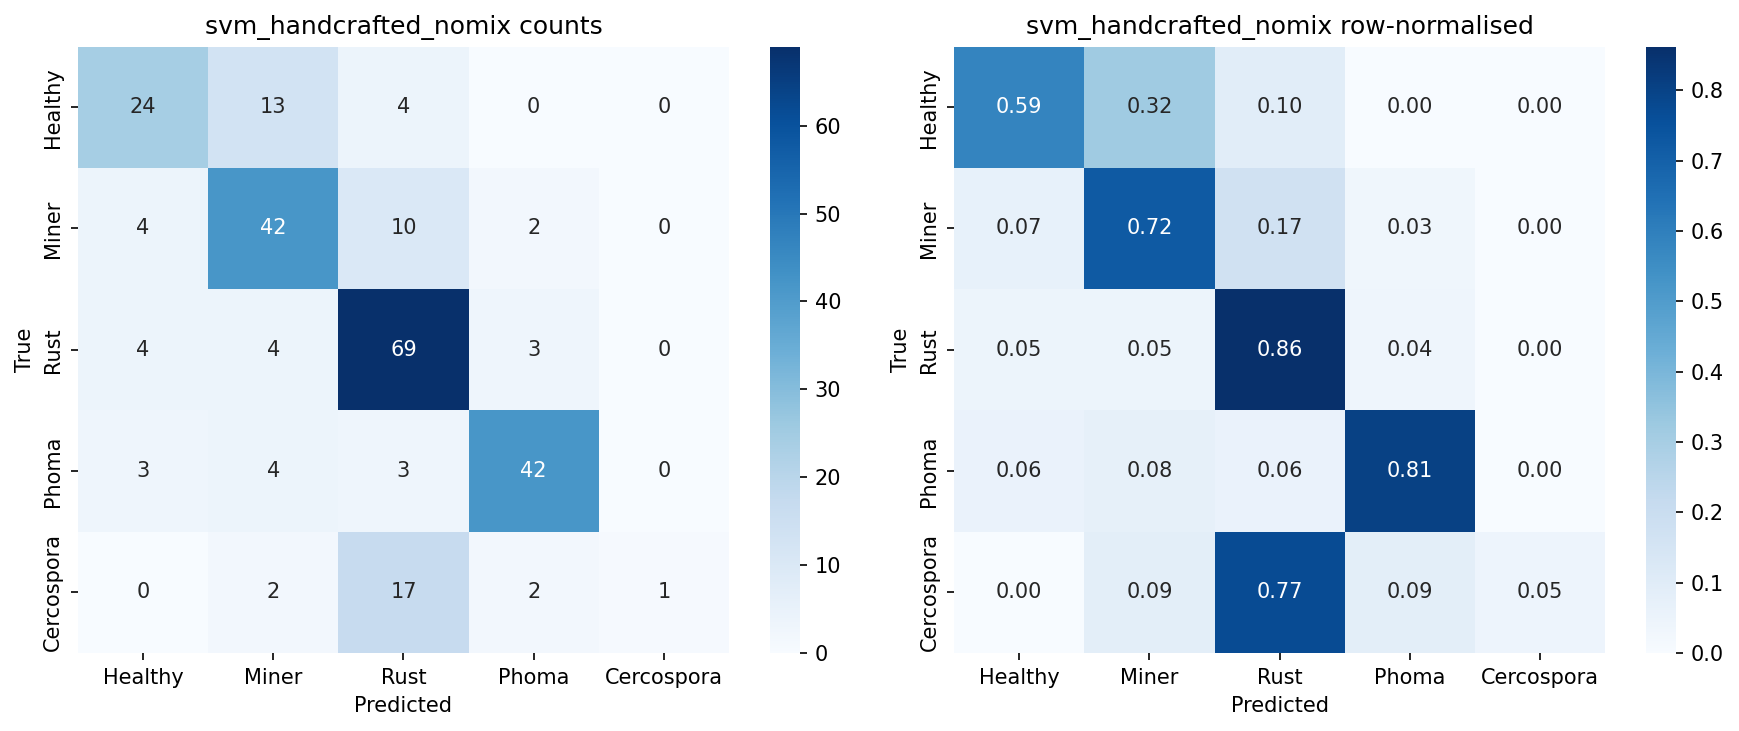

[svm_handcrafted_nomix] total 0:31


{'model': 'SVM', 'features': 'handcrafted', 'val_acc': 0.7035573122529645, 'test_acc': 0.7035573122529645, 'macro_f1': 0.5974487654696826, 'best_params': {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}}
{'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}


In [12]:
svm_hc = SVMPipeline(
    pack_hc, name="svm_handcrafted_nomix",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=False,
    C_grid=[0.1, 1, 10, 100],
    gamma_grid=["scale"],
    search_linear_first=True,
    skip_default_fit=True,
)
svm_hc.run()
record("SVM", "handcrafted", svm_hc)
print(svm_hc.best_params)


[svm_deep_nomix] start  train=1179 x 1280  search=25 RBF + 5 linear  proba=True


[svm_deep_nomix] ingest  scaling 1179 x 1280  elapsed 0:00


[svm_deep_nomix] ingest  done in 0:00  elapsed 0:00


[svm_deep_nomix] fit  default RBF C=1 gamma=scale  elapsed 0:00


[svm_deep_nomix] fit  done in 0:00  val_acc=0.842  elapsed 0:00


...

[svm_deep_nomix] search  27/30  linear C=1 gamma=scale  val_acc=0.842  0:00  remaining ~0:01  elapsed 0:12


[svm_deep_nomix] search  28/30  linear C=10 gamma=scale  val_acc=0.842  0:00  remaining ~0:01  elapsed 0:12


[svm_deep_nomix] search  29/30  linear C=100 gamma=scale  val_acc=0.842  0:00  remaining ~0:00  elapsed 0:13


[svm_deep_nomix] search  30/30  linear C=1000 gamma=scale  val_acc=0.842  0:00  remaining ~0:00  elapsed 0:13


[svm_deep_nomix] search  done  best={'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}  val_acc=0.870  elapsed 0:13


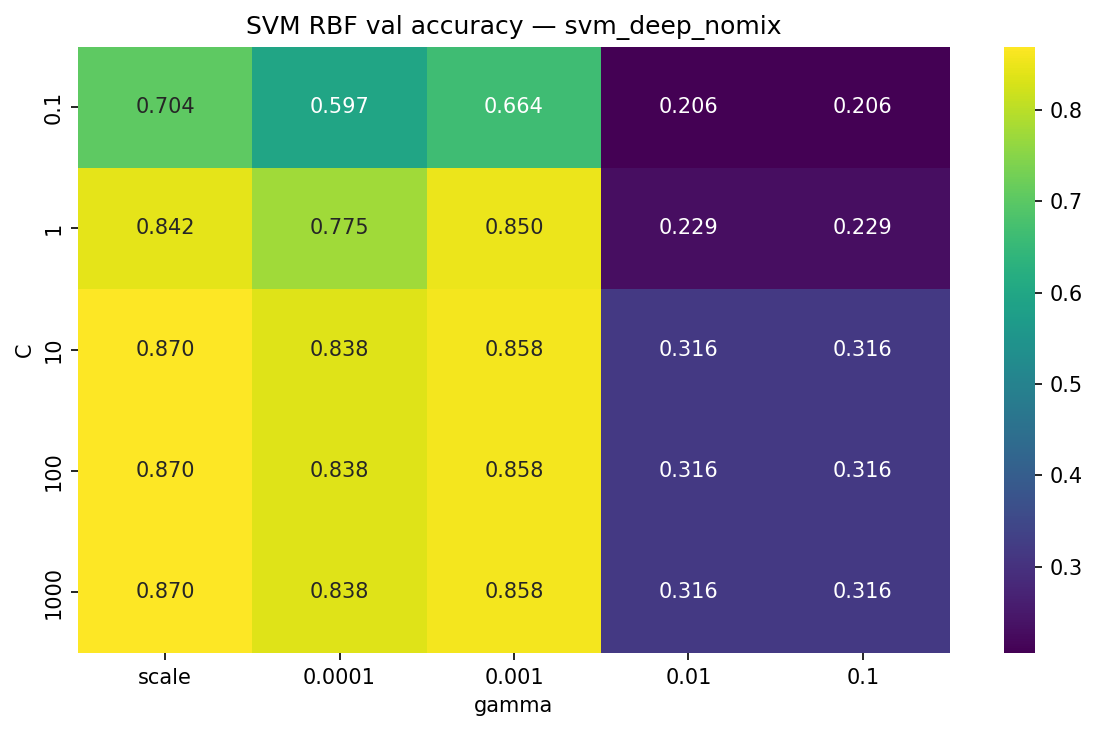

[svm_deep_nomix] refit  rbf C=10 gamma=scale  proba=True  elapsed 0:13


[svm_deep_nomix] refit  done in 0:02  elapsed 0:15


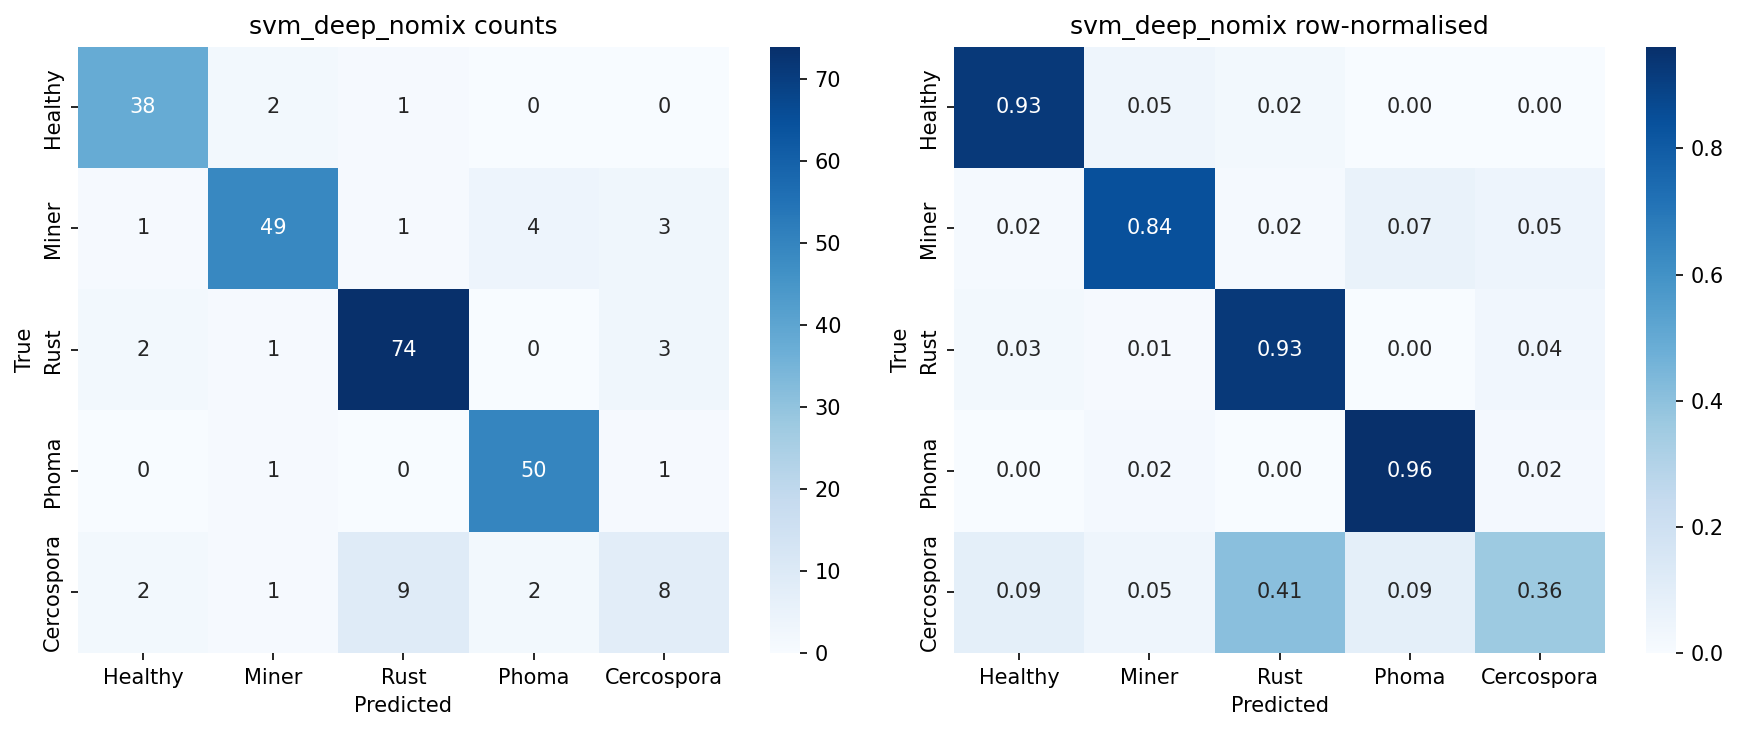

[svm_deep_nomix] total 0:15


{'model': 'SVM', 'features': 'deep (frozen EffNet)', 'val_acc': 0.8695652173913043, 'test_acc': 0.8656126482213439, 'macro_f1': 0.8070179920179921, 'best_params': {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}}
{'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}


In [13]:
svm_deep = SVMPipeline(
    pack_deep, name="svm_deep_nomix",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=True,
)
svm_deep.run()
record("SVM", "deep (frozen EffNet)", svm_deep)
print(svm_deep.best_params)


Best linear SVM on deep features (val): {'kernel': 'linear', 'C': 0.1, 'gamma': None, 'val_acc': 0.841897233201581}


{'model': 'SVM-linear (ablation)', 'features': 'deep (frozen EffNet)', 'val_acc': 0.841897233201581, 'test_acc': 0.8616600790513834, 'macro_f1': 0.8034730073347408, 'best_params': {'kernel': 'linear', 'C': 0.1}}


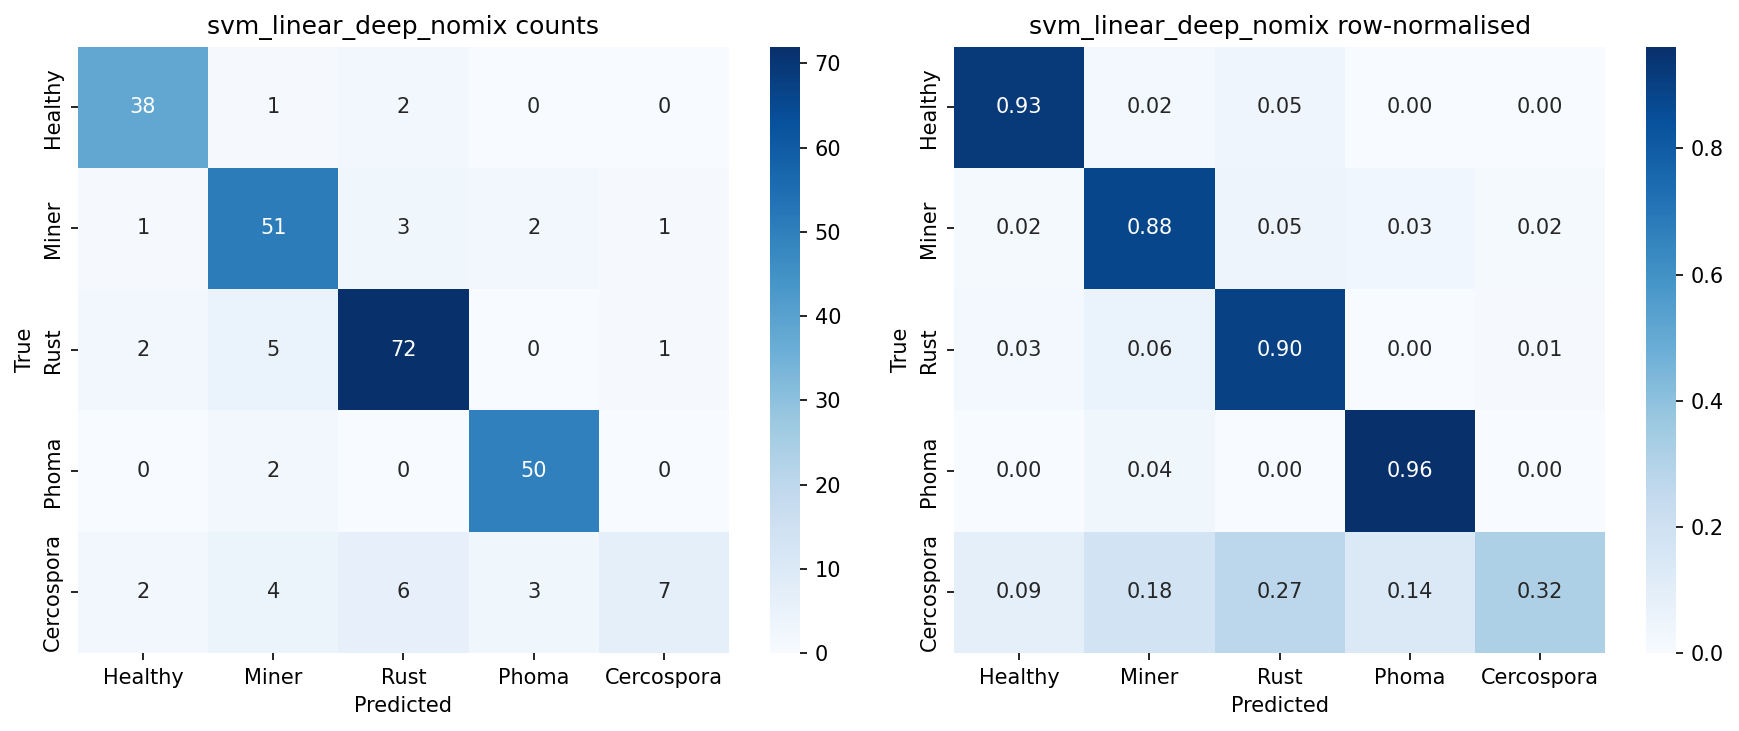

{'acc': 0.8616600790513834,
 'macro_f1': 0.8034730073347408,
 'weighted_f1': 0.8505781083658708,
 'macro_precision': 0.8495166612286255,
 'macro_recall': 0.7971719785681098}

In [14]:
linear_rows = [r for r in svm_deep.search_table if r["kernel"] == "linear"]
best_linear = max(linear_rows, key=lambda r: r["val_acc"])
print("Best linear SVM on deep features (val):", best_linear)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

scaled_deep, _ = scale_pack(pack_deep)
lin = SVC(kernel="linear", C=best_linear["C"], class_weight="balanced")
lin.fit(scaled_deep.X_train, scaled_deep.y_train)
pred_lin = lin.predict(scaled_deep.X_test)
pred_lin_val = lin.predict(scaled_deep.X_val)
record(
    "SVM-linear (ablation)",
    "deep (frozen EffNet)",
    val_acc=float(accuracy_score(scaled_deep.y_val, pred_lin_val)),
    test_acc=float(accuracy_score(scaled_deep.y_test, pred_lin)),
    macro_f1=float(f1_score(scaled_deep.y_test, pred_lin, average="macro", zero_division=0)),
    best_params={"kernel": "linear", "C": best_linear["C"]},
)
svm_deep.report(scaled_deep.y_test, pred_lin, "svm_linear_deep_nomix")


Optional PCA pack for SVM. Same loop, smaller vectors. Useful if the 1280-d RBF grid is slow.


[svm_pca256_nomix] start  train=1179 x 256  search=25 RBF + 5 linear  proba=False


[svm_pca256_nomix] ingest  scaling 1179 x 256  elapsed 0:00


[svm_pca256_nomix] ingest  done in 0:00  elapsed 0:00


[svm_pca256_nomix] fit  default RBF C=1 gamma=scale  elapsed 0:00


[svm_pca256_nomix] fit  done in 0:00  val_acc=0.834  elapsed 0:00


...

[svm_pca256_nomix] search  27/30  linear C=1 gamma=scale  val_acc=0.755  0:00  remaining ~0:00  elapsed 0:03


[svm_pca256_nomix] search  28/30  linear C=10 gamma=scale  val_acc=0.755  0:00  remaining ~0:00  elapsed 0:03


[svm_pca256_nomix] search  29/30  linear C=100 gamma=scale  val_acc=0.755  0:00  remaining ~0:00  elapsed 0:03


[svm_pca256_nomix] search  30/30  linear C=1000 gamma=scale  val_acc=0.755  0:00  remaining ~0:00  elapsed 0:04


[svm_pca256_nomix] search  done  best={'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}  val_acc=0.850  elapsed 0:04


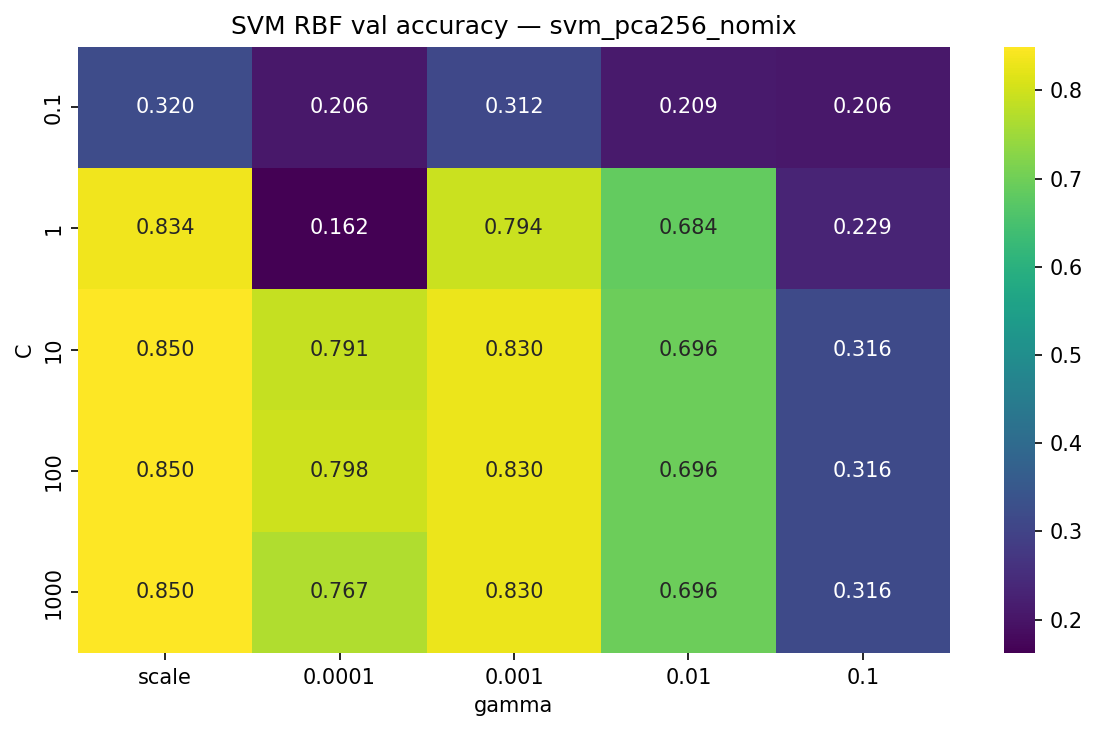

[svm_pca256_nomix] refit  rbf C=10 gamma=scale  proba=False  elapsed 0:04


[svm_pca256_nomix] refit  done in 0:00  elapsed 0:04


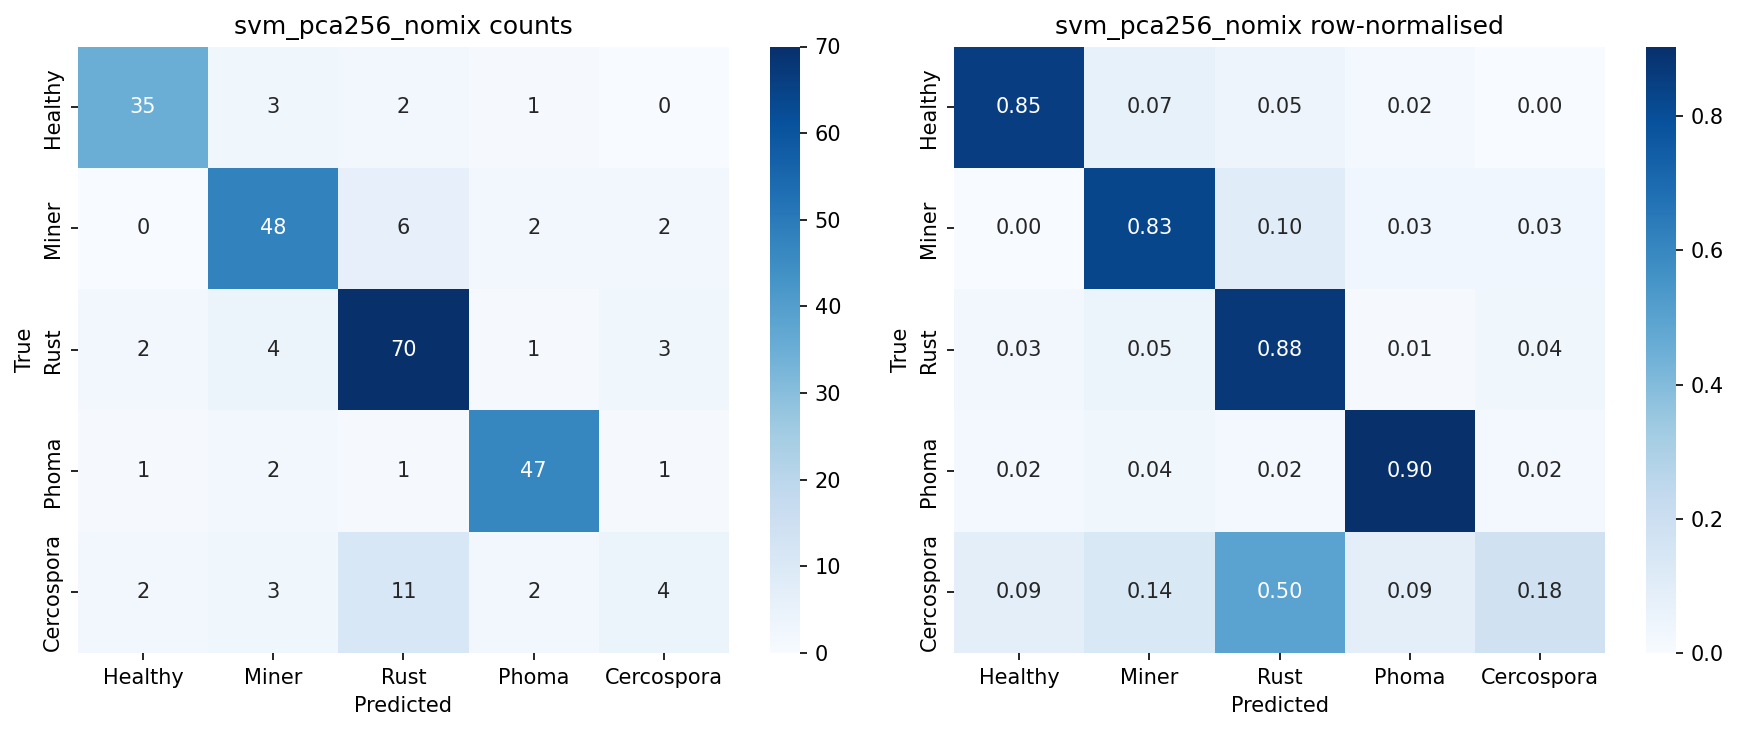

[svm_pca256_nomix] total 0:04


{'model': 'SVM', 'features': 'deep PCA-256', 'val_acc': 0.849802371541502, 'test_acc': 0.8063241106719368, 'macro_f1': 0.7293048719801793, 'best_params': {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}}


In [15]:
svm_pca = SVMPipeline(
    pack_pca, name="svm_pca256_nomix",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=False,
)
svm_pca.run()
record("SVM", "deep PCA-256", svm_pca)


### Model 1 literature note

Margin classifiers on frozen CNN embeddings are a standard transfer-learning probe. We are not copying Esgario's protocol here: they fine-tune ResNet-50 on pixels. The SVM numbers answer a different question: how much of the disease signal is already in ImageNet features.


## 9. Model 2 — EfficientNet-B0, full grading loop

Personalized ingest: raw 224×224 RGB. MixUp plus flips. Phase 1 trains the head with a frozen backbone. Phase 2 opens the last layers at a lower learning rate. Early stopping watches validation loss. Test is scored once after search.


Epoch 1/12


2026-08-28 20:15:15.738759: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[16,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,480,14,14]{3,2,1,0}, f32[480,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-08-28 20:15:15.910085: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.172019171s
Trying algorithm eng3{k11=2} for conv (f32[16,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,480,14,14]{3,2,1,0}, f32[480,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn

2026-08-28 20:15:16.409962: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-28 20:15:16.599145: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-28 20:15:17.379468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-28 20:15:17.737825: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...

61/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7151 - loss: 1.1304

65/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7167 - loss: 1.1302

69/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7181 - loss: 1.1303

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7194 - loss: 1.1306

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7422 - loss: 1.1305 - val_accuracy: 0.7787 - val_loss: 0.6299 - learning_rate: 2.5000e-06


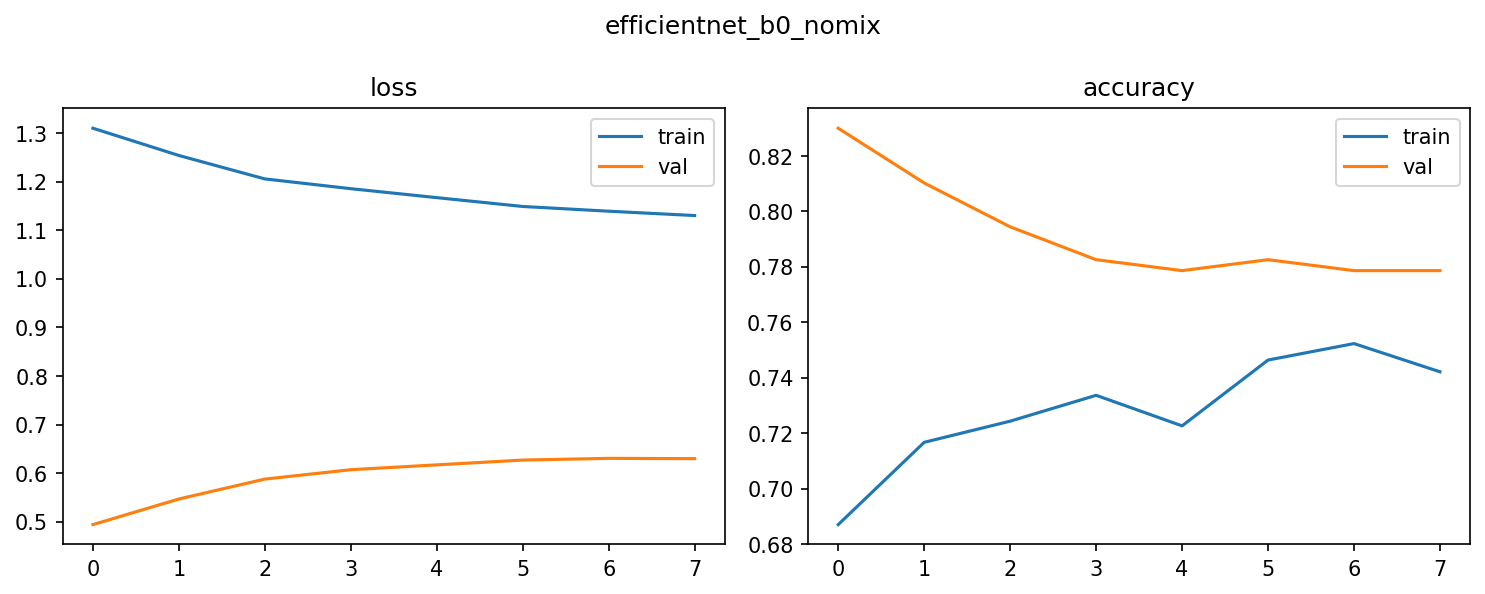

Epoch 1/12


 1/74 ━━━━━━━━━━━━━━━━━━━━ 13:51 11s/step - accuracy: 0.0625 - loss: 1.7179

 4/74 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0794 - loss: 1.7230  

 7/74 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1035 - loss: 1.7027

10/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1147 - loss: 1.6765

...

61/74 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7409 - loss: 1.1676

65/74 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7408 - loss: 1.1665

69/74 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7408 - loss: 1.1657

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7407 - loss: 1.1650

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7413 - loss: 1.1497 - val_accuracy: 0.7747 - val_loss: 0.5946 - learning_rate: 2.5000e-06


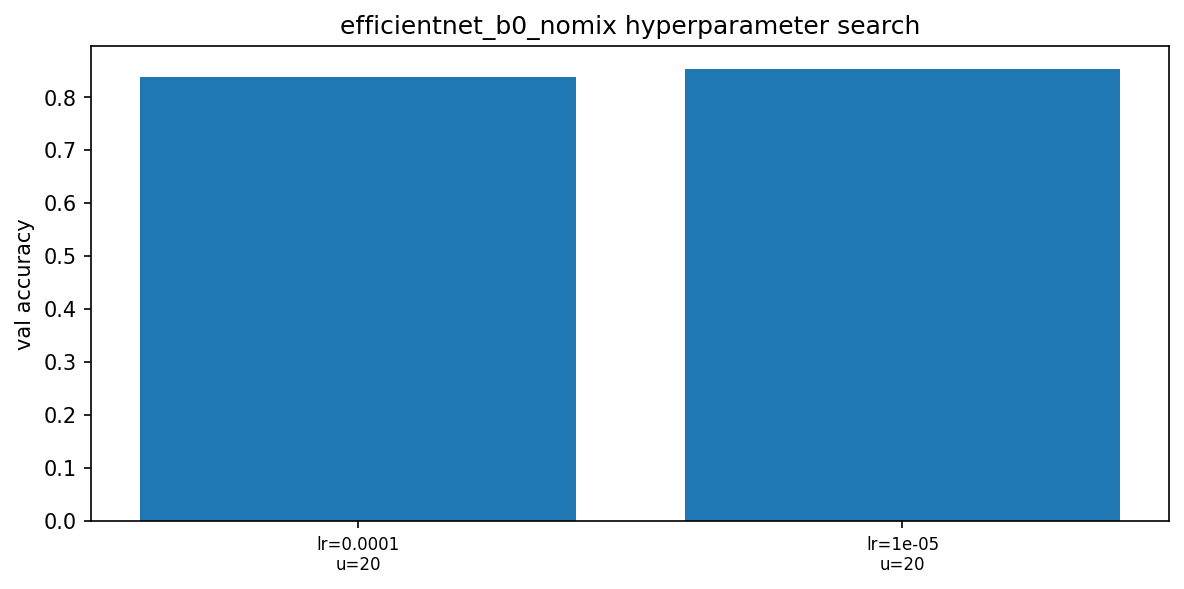

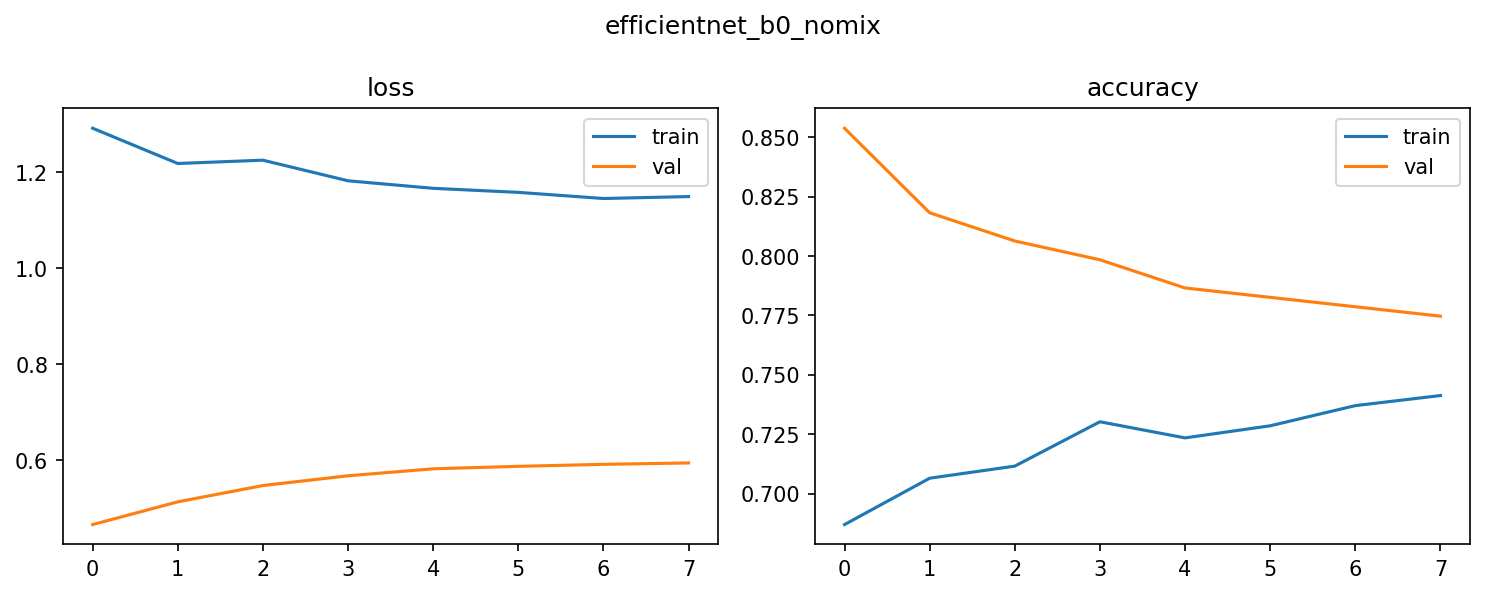

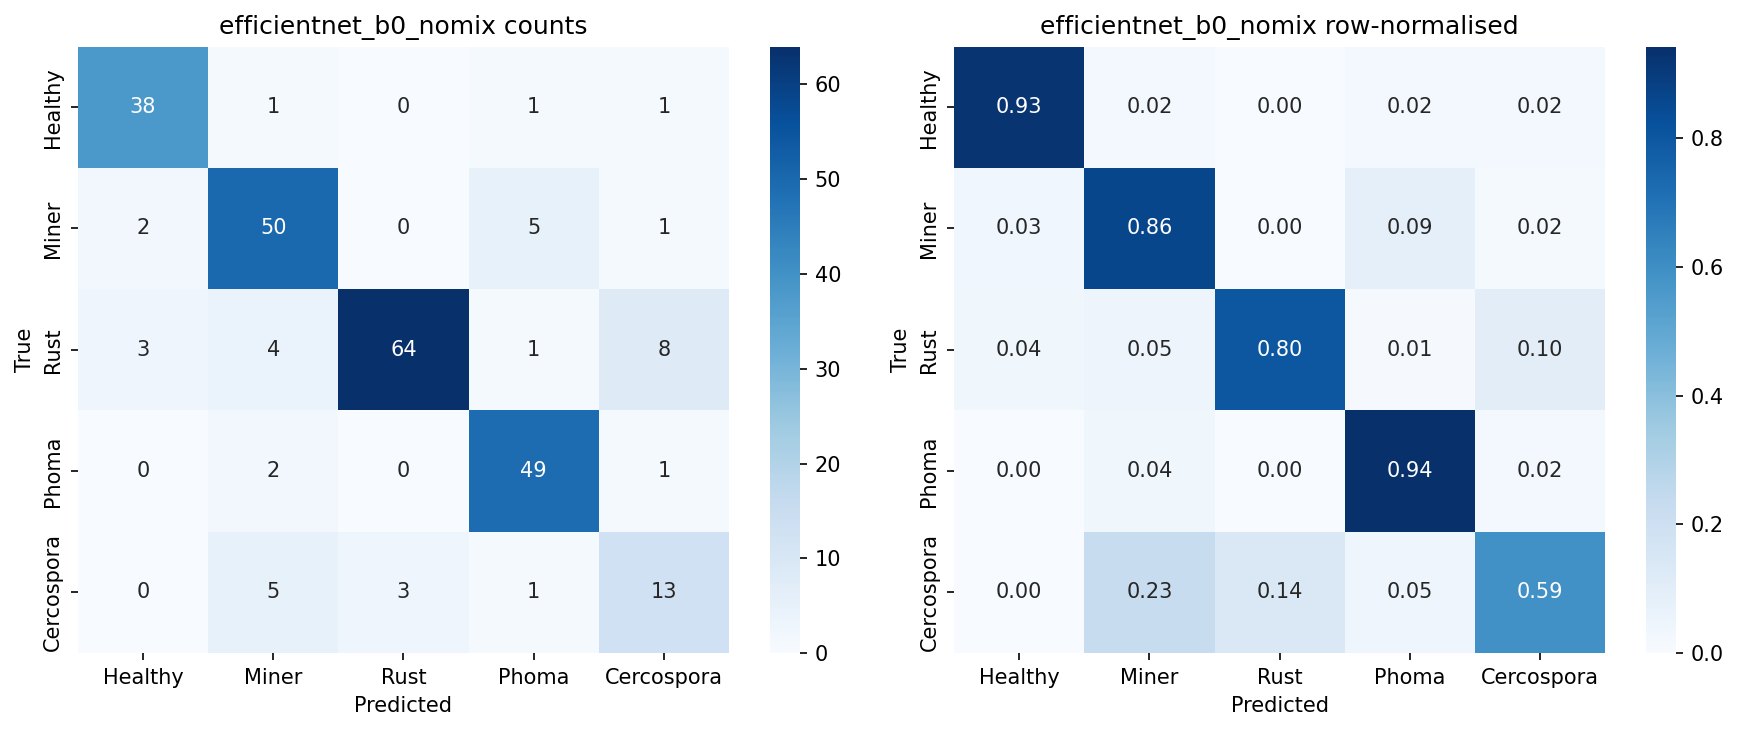

{'model': 'EfficientNet-B0', 'features': 'raw images', 'val_acc': 0.8537549407114624, 'test_acc': 0.8458498023715415, 'macro_f1': 0.8146286995053307, 'best_params': {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20}}
EffNet best params: {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20}


In [16]:
effnet = EfficientNetPipeline(
    dataset, split,
    name="efficientnet_b0_nomix",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=True,
    ingest_hsv_crop=True,
    epochs_head=12,
    epochs_ft=20,
    batch_size=16,
    search_grid=[
        {"lr": 1e-4, "dropout": 0.3, "unfreeze": 20},
        {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20},
    ],
)
effnet.run()
record("EfficientNet-B0", "raw images", effnet)
print("EffNet best params:", effnet.best_params)


## 10. Extras (criterion i)


### 10.1 XGBoost on the same cached features


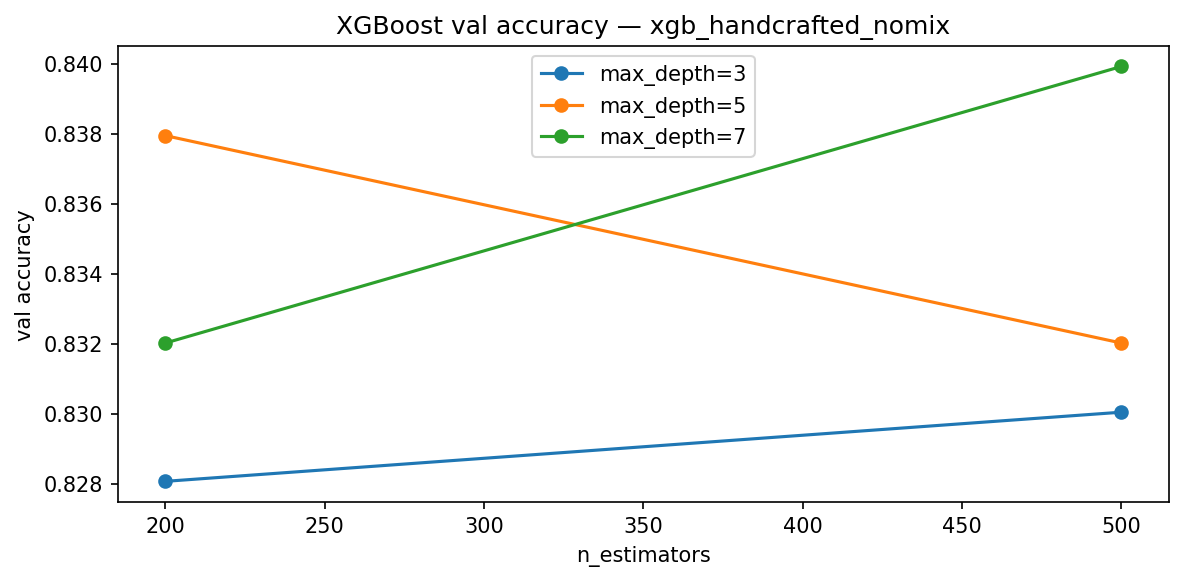

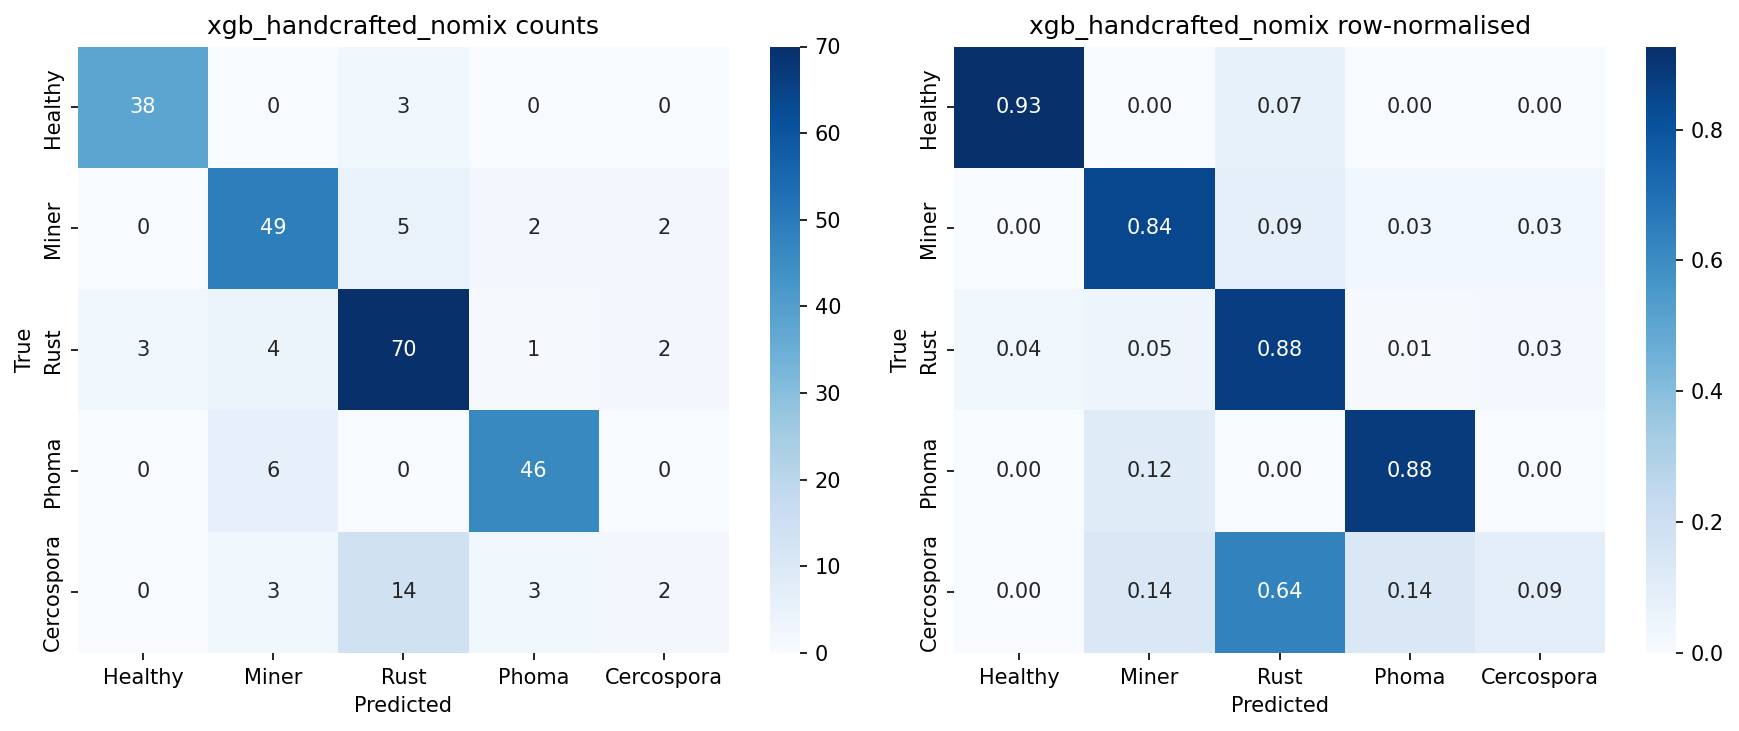

{'model': 'XGBoost', 'features': 'handcrafted', 'val_acc': 0.841897233201581, 'test_acc': 0.8102766798418972, 'macro_f1': 0.7169843901607941, 'best_params': {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}}


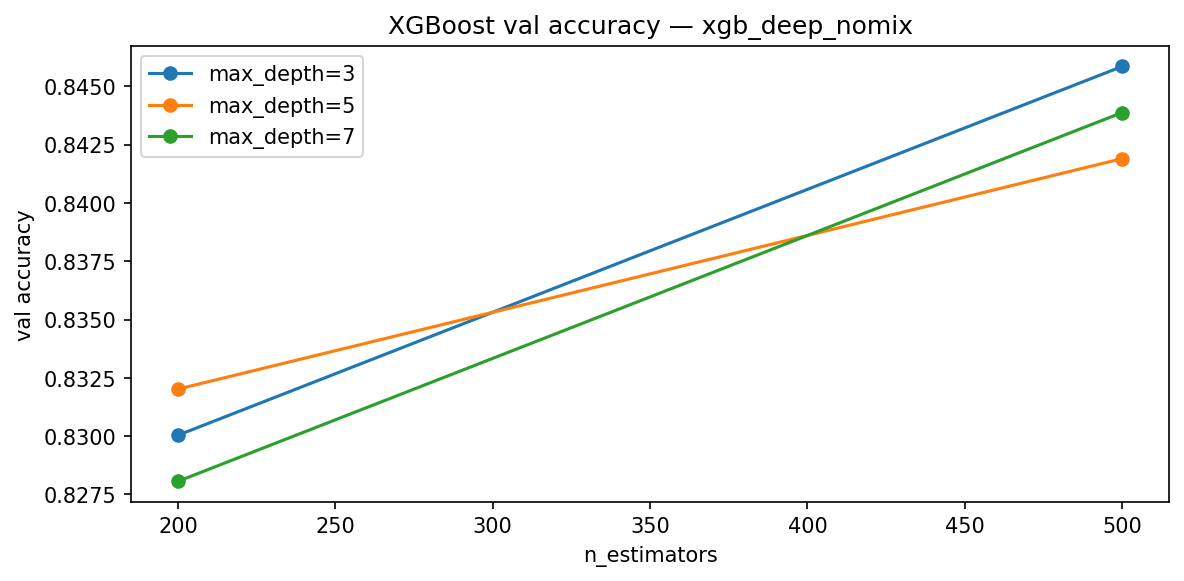

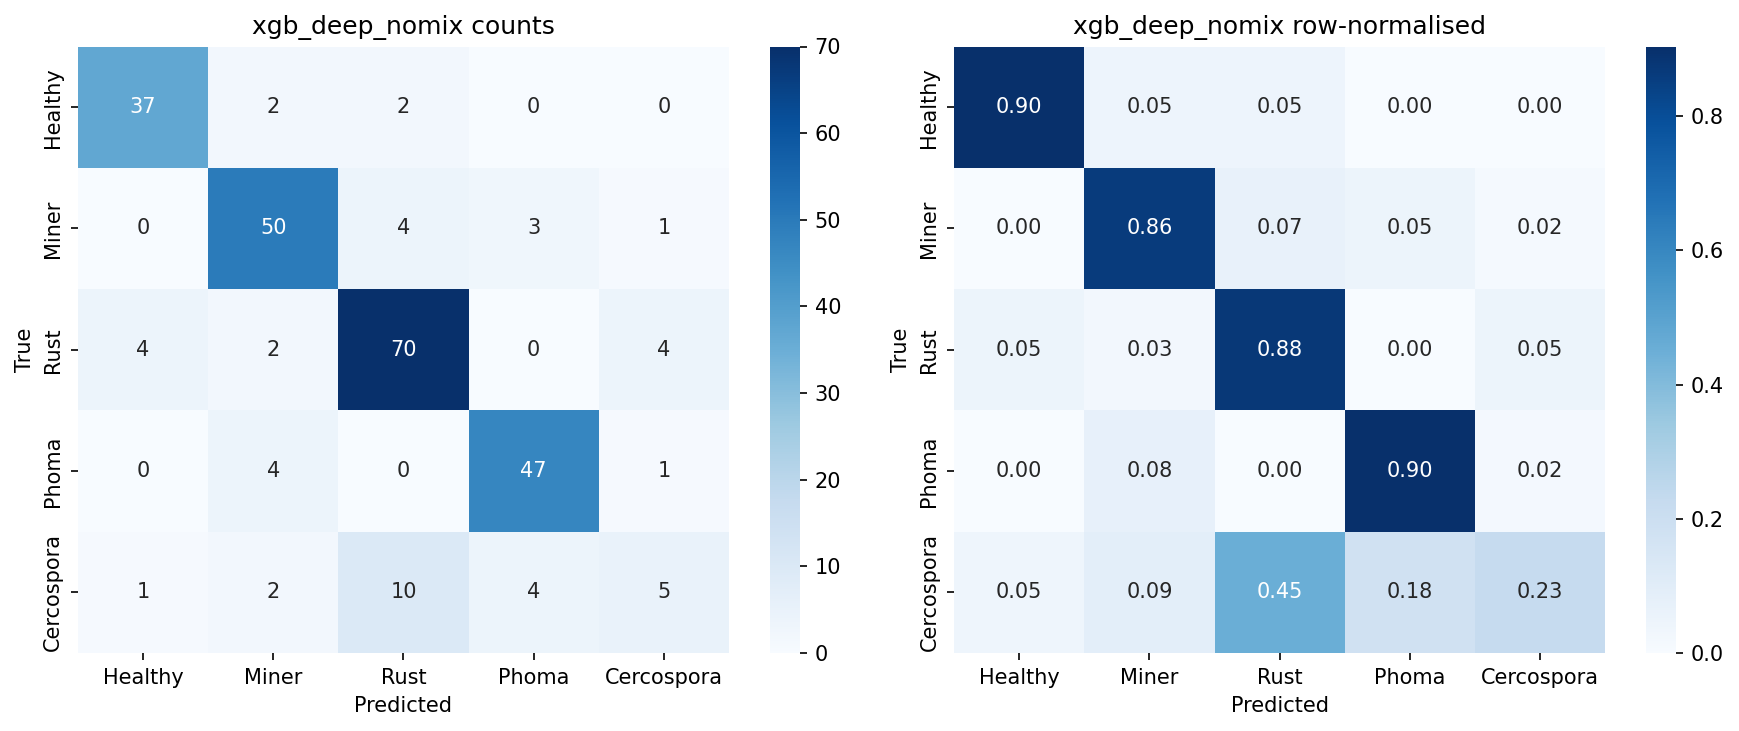

{'model': 'XGBoost', 'features': 'deep (frozen EffNet)', 'val_acc': 0.8458498023715415, 'test_acc': 0.8260869565217391, 'macro_f1': 0.754444028403056, 'best_params': {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05}}


In [17]:
xgb_hc = XGBoostPipeline(
    pack_hc, name="xgb_handcrafted_nomix",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
)
xgb_hc.run()
record("XGBoost", "handcrafted", xgb_hc)

xgb_deep = XGBoostPipeline(
    pack_deep, name="xgb_deep_nomix",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
)
xgb_deep.run()
record("XGBoost", "deep (frozen EffNet)", xgb_deep)


### 10.2 ResNet-50 (third method, same protocol as EfficientNet)


Epoch 1/10


 1/74 ━━━━━━━━━━━━━━━━━━━━ 9:18 8s/step - accuracy: 0.1875 - loss: 2.4320

 3/74 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2465 - loss: 2.2299

 5/74 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2373 - loss: 2.1492

 7/74 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2365 - loss: 2.1066

...

67/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9928 - loss: 0.0950

69/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9929 - loss: 0.0946

71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9931 - loss: 0.0942

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9932 - loss: 0.0938

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9983 - loss: 0.0804 - val_accuracy: 0.8577 - val_loss: 0.4575 - learning_rate: 1.0000e-05


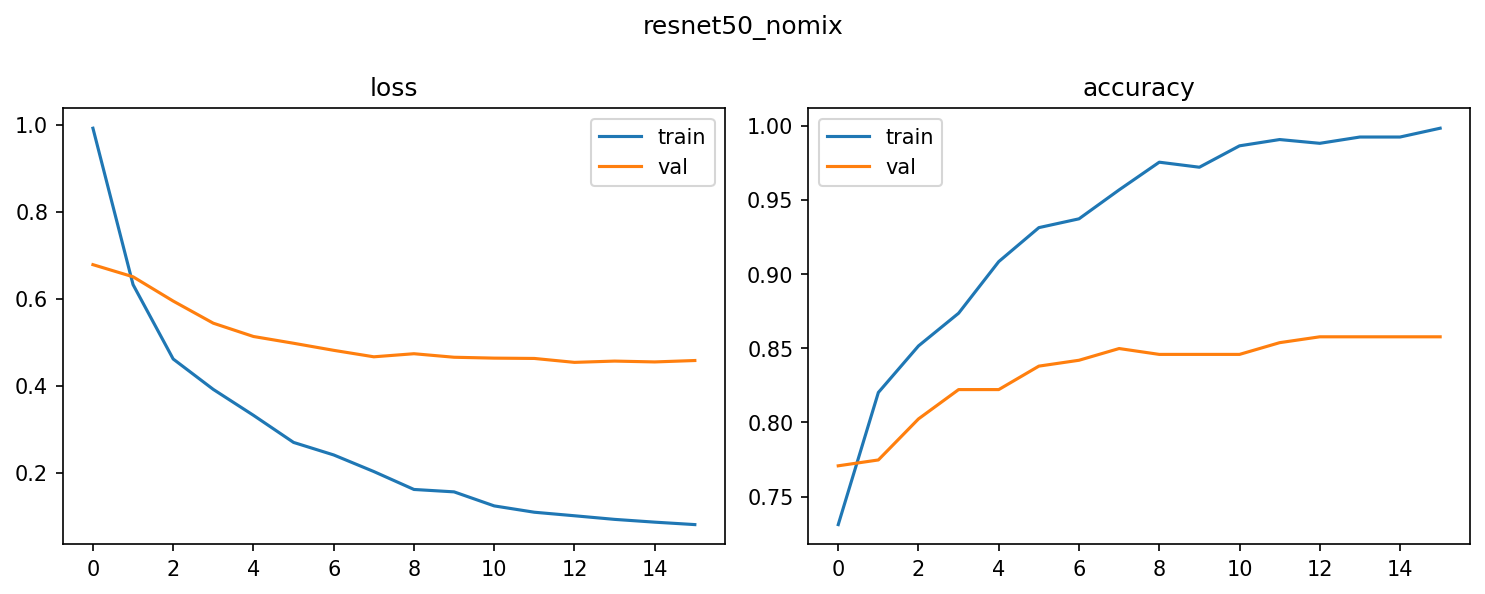

Epoch 1/10


 1/74 ━━━━━━━━━━━━━━━━━━━━ 7:27 6s/step - accuracy: 0.1250 - loss: 2.2052

 3/74 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.1389 - loss: 2.1514

 5/74 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1602 - loss: 2.0975

 7/74 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.1816 - loss: 2.0716

...

67/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9989 - loss: 0.0791

69/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9988 - loss: 0.0791

71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9987 - loss: 0.0791

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9987 - loss: 0.0791

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9966 - loss: 0.0793 - val_accuracy: 0.8617 - val_loss: 0.4492 - learning_rate: 5.0000e-06


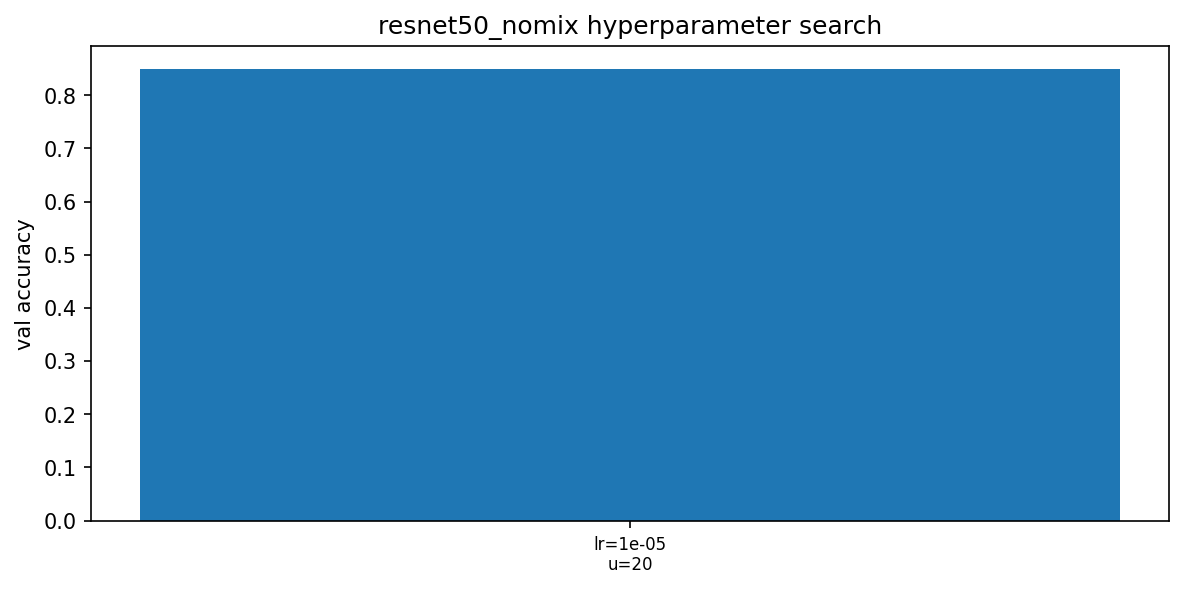

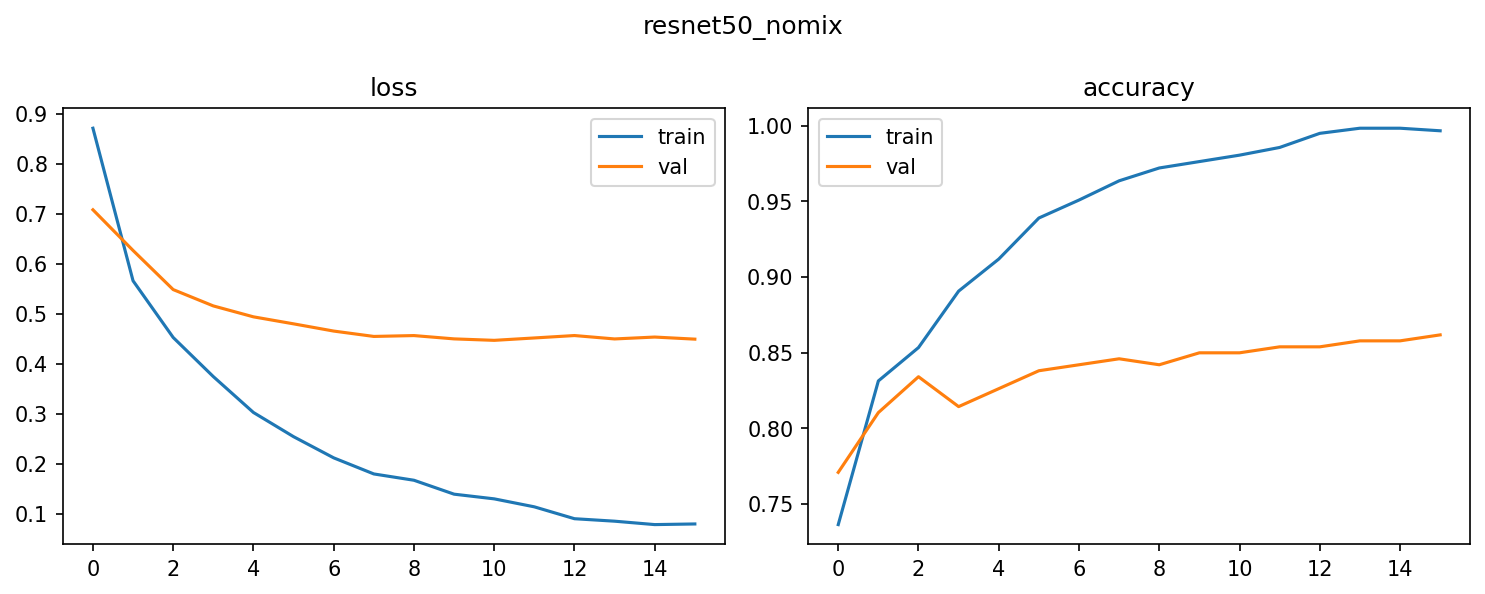

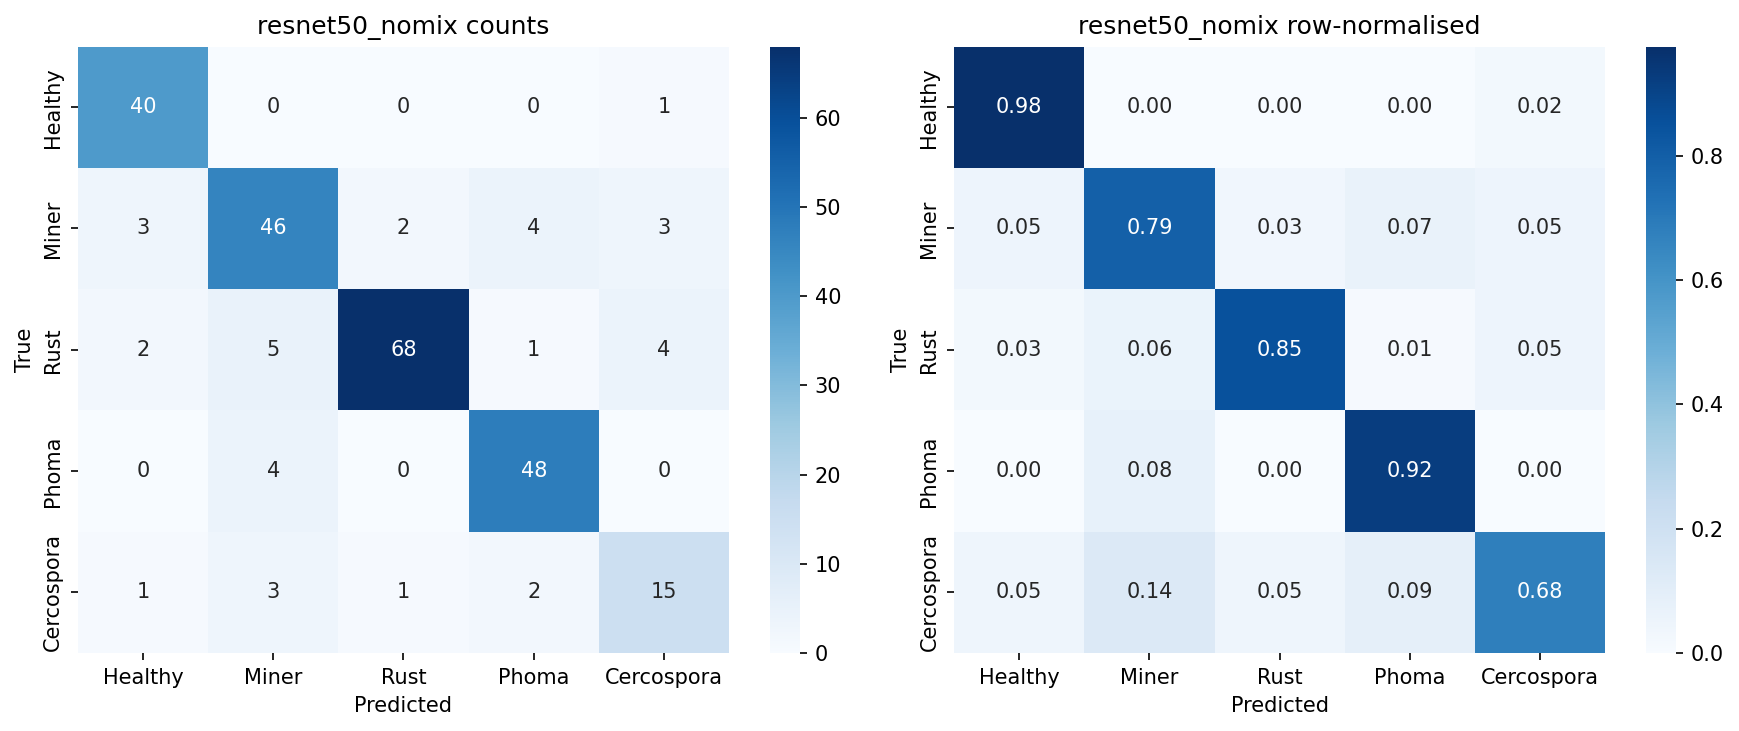

{'model': 'ResNet-50', 'features': 'raw images', 'val_acc': 0.849802371541502, 'test_acc': 0.857707509881423, 'macro_f1': 0.8354337716330917, 'best_params': {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20}}


In [18]:
resnet = ResNetPipeline(
    dataset, split,
    name="resnet50_nomix",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=True,
    ingest_hsv_crop=True,
    epochs_head=10,
    epochs_ft=16,
    batch_size=16,
    search_grid=[
        {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20},
    ],
)
resnet.run()
record("ResNet-50", "raw images", resnet)


### 10.3 MixUp on/off ablation on EfficientNet (short run)


Epoch 1/8


 1/74 ━━━━━━━━━━━━━━━━━━━━ 14:49 12s/step - accuracy: 0.0000e+00 - loss: 1.6783

 4/74 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0820 - loss: 1.6994      

 7/74 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1050 - loss: 1.7056

10/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1329 - loss: 1.6954

...

60/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8152 - loss: 0.5256

64/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8150 - loss: 0.5267

68/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8146 - loss: 0.5282

72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8144 - loss: 0.5294

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8109 - loss: 0.5491 - val_accuracy: 0.8063 - val_loss: 0.5151 - learning_rate: 2.5000e-06


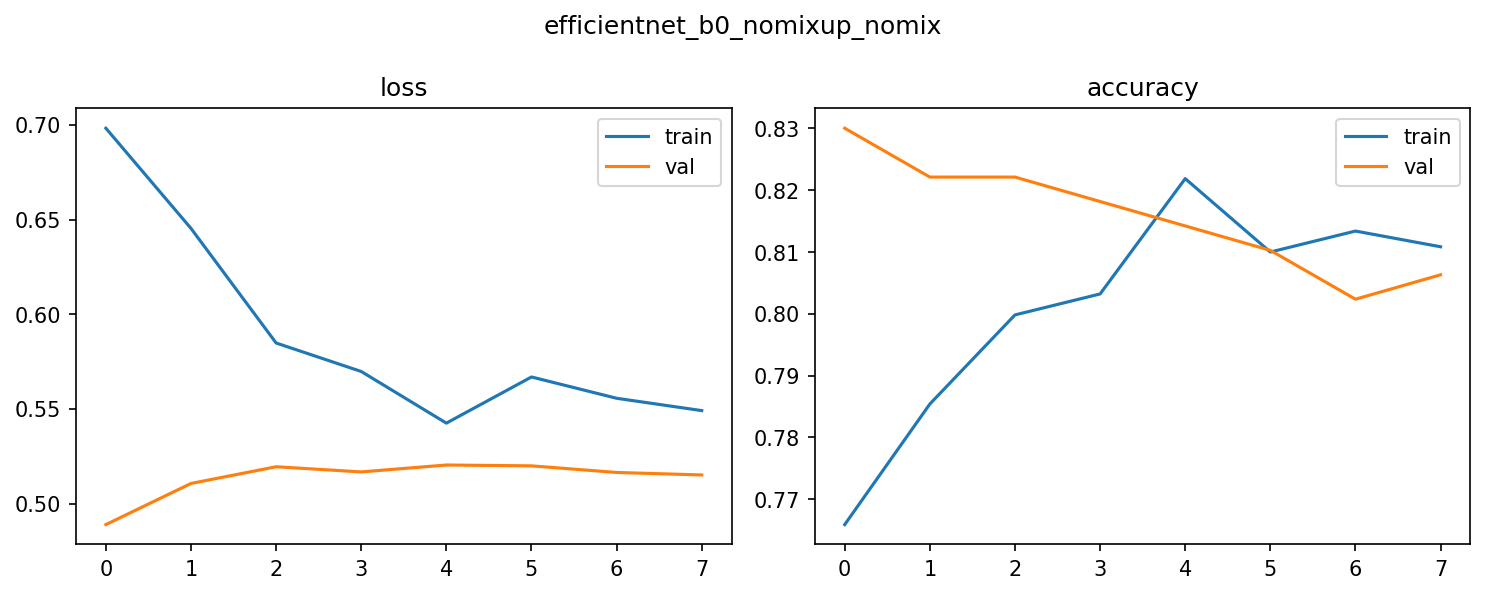

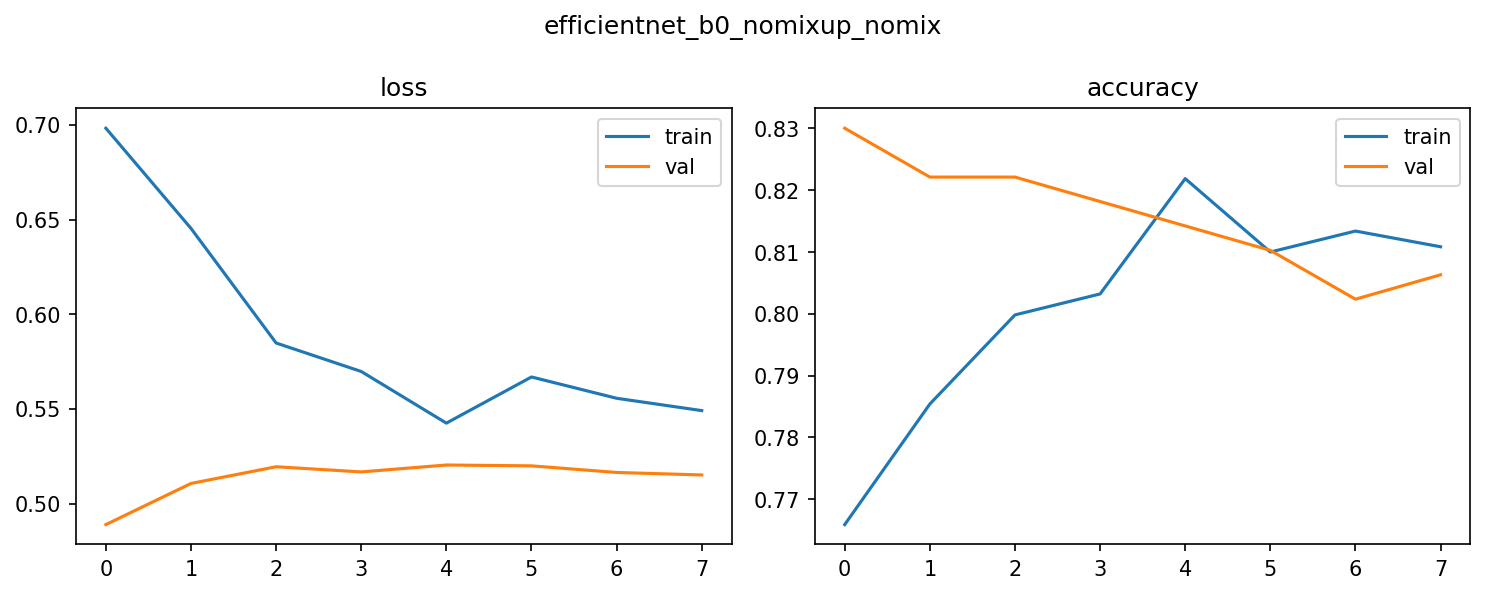

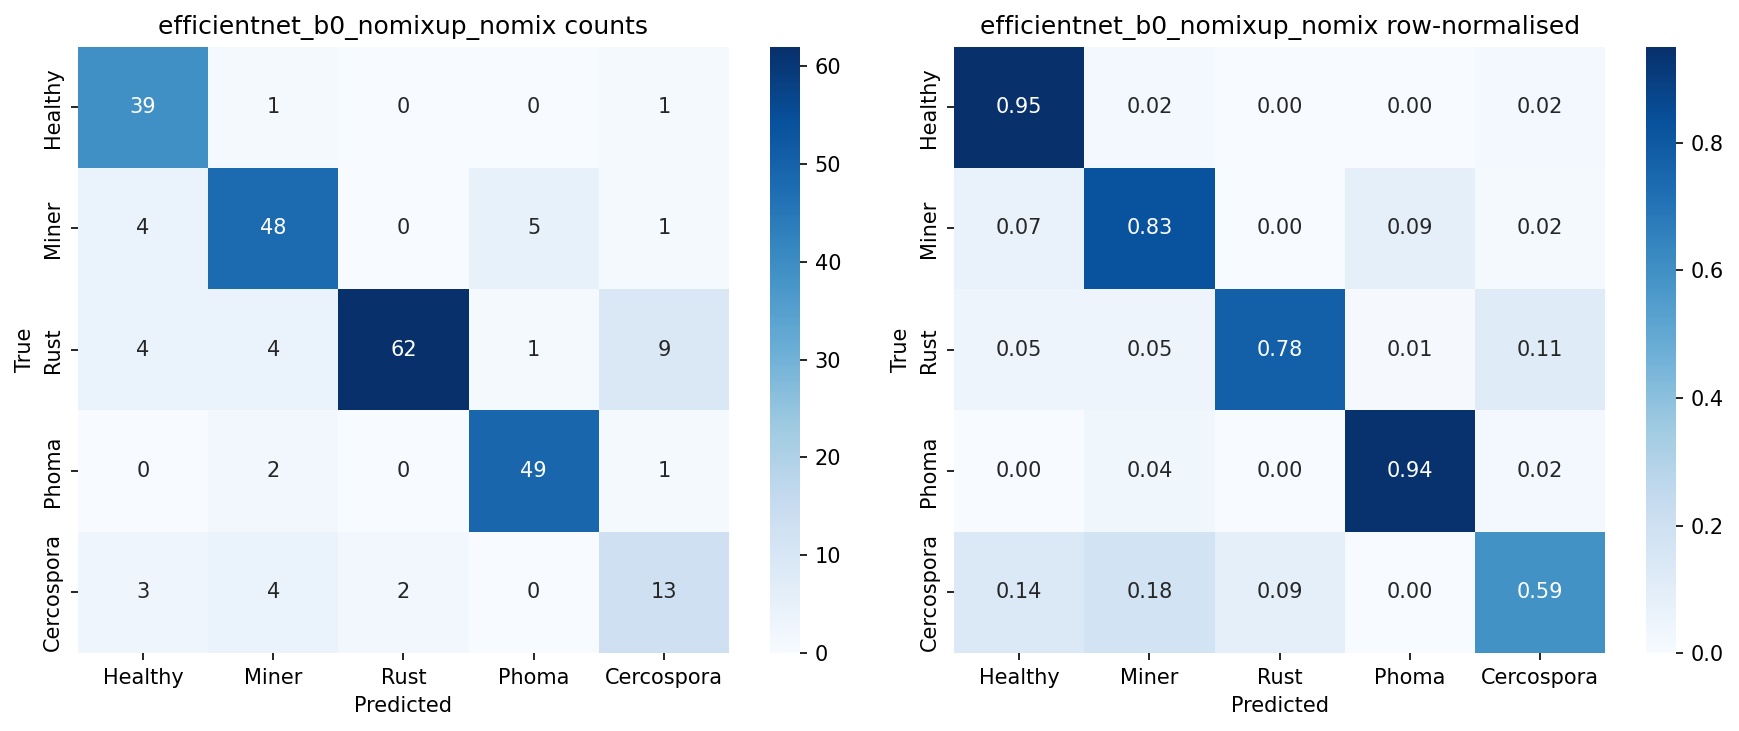

{'model': 'EfficientNet-B0 (no MixUp)', 'features': 'raw images', 'val_acc': 0.8300395256916996, 'test_acc': 0.83399209486166, 'macro_f1': 0.801569225719156, 'best_params': {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20, 'mixup': False}}


In [19]:
effnet_nomixup = EfficientNetPipeline(
    dataset, split,
    name="efficientnet_b0_nomixup_nomix",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=False,
    ingest_hsv_crop=True,
    epochs_head=8,
    epochs_ft=12,
    batch_size=16,
    search_grid=[{"lr": 1e-5, "dropout": 0.3, "unfreeze": 20}],
)
effnet_nomixup.ingest()
effnet_nomixup.fit()
effnet_nomixup.best_params = {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20, "mixup": False}
effnet_nomixup.refit()
effnet_nomixup.test_metrics = effnet_nomixup.report(
    effnet_nomixup.y_true_test, effnet_nomixup.y_pred_test, effnet_nomixup.name
)
record("EfficientNet-B0 (no MixUp)", "raw images", effnet_nomixup)


### 10.4 Probability ensemble


Ensemble SVM-deep + EffNet: {'acc': 0.8656126482213439, 'macro_f1': 0.8303284247320744, 'weighted_f1': 0.8656073994407152, 'macro_precision': 0.8297931697931699, 'macro_recall': 0.8312803701765012}


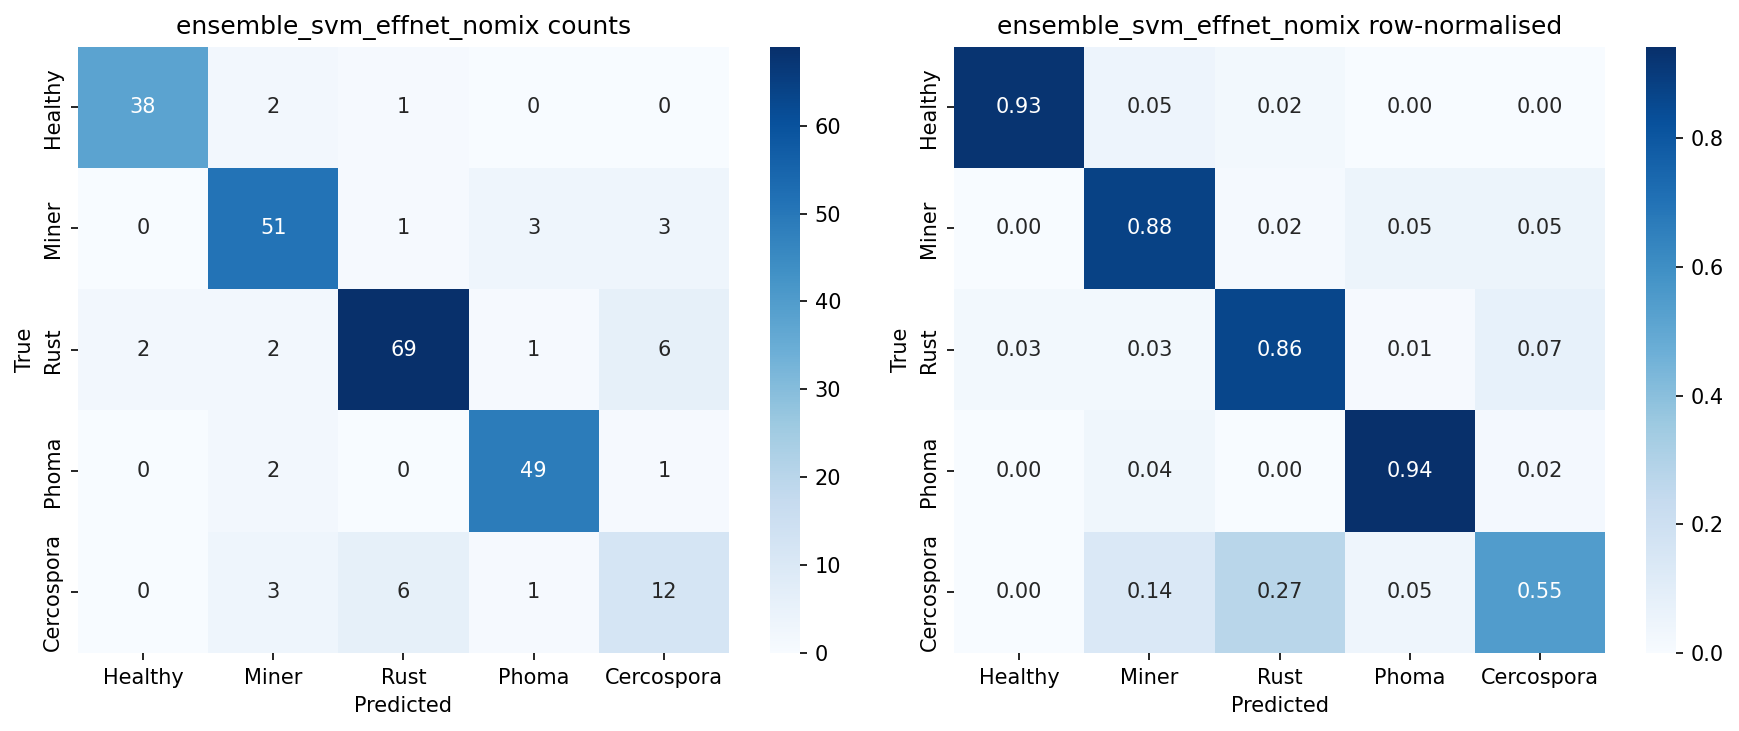

{'model': 'Ensemble', 'features': 'SVM-deep + EffNet', 'val_acc': None, 'test_acc': 0.8656126482213439, 'macro_f1': 0.8303284247320744, 'best_params': {'combine': 'mean_proba'}}
Ensemble + ResNet: {'acc': 0.8774703557312253, 'macro_f1': 0.8363244720826858, 'weighted_f1': 0.8781444999779037, 'macro_precision': 0.8331562106848146, 'macro_recall': 0.8402101430949201}
{'model': 'Ensemble', 'features': 'SVM-deep + EffNet + ResNet', 'val_acc': None, 'test_acc': 0.8774703557312253, 'macro_f1': 0.8363244720826858, 'best_params': {'combine': 'mean_proba'}}


In [20]:
from sklearn.metrics import accuracy_score, f1_score

proba_svm = svm_deep.proba_test
proba_eff = effnet.proba_test
proba_ens = ensemble_average(proba_svm, proba_eff)
y_ens = np.argmax(proba_ens, axis=1)
y_test = svm_deep.y_true_test
ens_metrics = classification_metrics(y_test, y_ens)
print("Ensemble SVM-deep + EffNet:", ens_metrics)
svm_deep.report(y_test, y_ens, "ensemble_svm_effnet_nomix")
record(
    "Ensemble",
    "SVM-deep + EffNet",
    val_acc=None,
    test_acc=ens_metrics["acc"],
    macro_f1=ens_metrics["macro_f1"],
    best_params={"combine": "mean_proba"},
)

if resnet.proba_test is not None:
    proba_3 = ensemble_average(proba_svm, proba_eff, resnet.proba_test)
    y3 = np.argmax(proba_3, axis=1)
    m3 = classification_metrics(y_test, y3)
    print("Ensemble + ResNet:", m3)
    record(
        "Ensemble",
        "SVM-deep + EffNet + ResNet",
        val_acc=None,
        test_acc=m3["acc"],
        macro_f1=m3["macro_f1"],
        best_params={"combine": "mean_proba"},
    )


### 10.5 Residual Mixed rule — skipped

No class 5 in this notebook, so the residual Mixed rule is not run.


In [21]:
print('Residual Mixed rule skipped (no class 5).')


Residual Mixed rule skipped (no class 5).


## 11. BRACOL YOLO cross-check

YOLO class ids are **not** the same as `predominant_stress`. Mapping: Cercospora=0→4, Miner=1→1, Phoma=2→3, Rust=3→2. Filenames look like `1_jpg.rf.{hash}.txt`.


BRACOL images with labels: 1744
Compared: 253 agreement: 0.7312252964426877
Errors where YOLO has multiple lesion types: 18


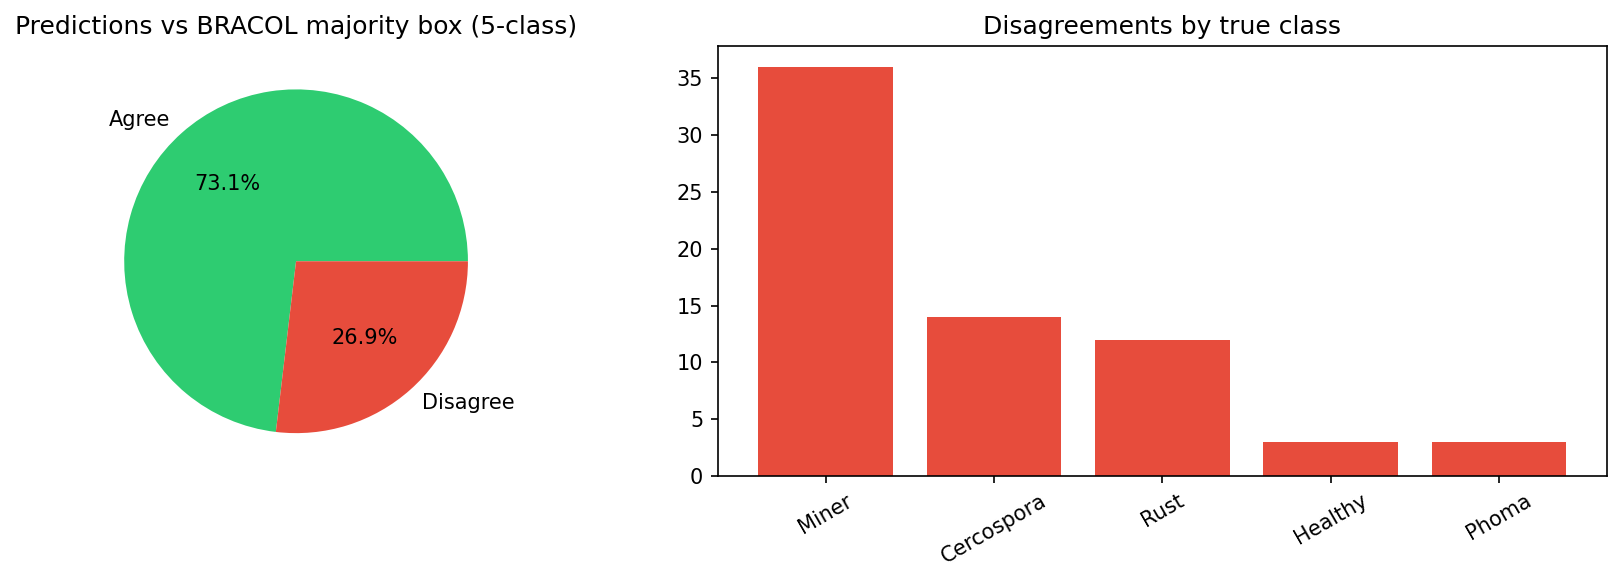

In [22]:
bracol = load_bracol_labels(PATHS["bracol_dir"])
print("BRACOL images with labels:", len(bracol))

test_ids = df.iloc[split.test_idx]["id"].values
best_preds = y_ens if "y_ens" in dir() else svm_deep.y_pred_test
y_true = svm_deep.y_true_test

rows_cmp = []
for i, img_id in enumerate(test_ids):
    if img_id not in bracol:
        continue
    dets = bracol[img_id]
    if len(dets) == 0:
        bracol_lab = 0
    else:
        most = max(set(dets), key=dets.count)
        bracol_lab = BRACOL_TO_STRESS.get(most, -1)
    rows_cmp.append({
        "id": int(img_id),
        "true": STRESS_NAMES.get(int(y_true[i]), str(y_true[i])),
        "ours": STRESS_NAMES.get(int(best_preds[i]), str(best_preds[i])),
        "bracol": STRESS_NAMES.get(int(bracol_lab), str(bracol_lab)),
        "n_det": len(dets),
        "multi_lesion": len(set(dets)) > 1,
        "agree": int(bracol_lab == best_preds[i]),
    })

comp = pd.DataFrame(rows_cmp)
if len(comp):
    print("Compared:", len(comp), "agreement:", float(comp["agree"].mean()))
    print("Errors where YOLO has multiple lesion types:",
          int(((comp["agree"] == 0) & comp["multi_lesion"]).sum()))
    comp.to_csv(os.path.join(PATHS["results_dir"], "bracol_crosscheck_nomix.csv"), index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].pie(
        [comp["agree"].sum(), (1 - comp["agree"]).sum()],
        labels=["Agree", "Disagree"], autopct="%1.1f%%",
        colors=["#2ecc71", "#e74c3c"],
    )
    axes[0].set_title("Predictions vs BRACOL majority box (5-class)")
    disagree = comp[comp["agree"] == 0]
    if len(disagree):
        vc = disagree["true"].value_counts()
        axes[1].bar(vc.index.astype(str), vc.values, color="#e74c3c")
        axes[1].tick_params(axis="x", rotation=30)
        axes[1].set_title("Disagreements by true class")
    fig.tight_layout()
    save_and_show(fig, "bracol_crosscheck_nomix.png", PATHS["figures_dir"])
else:
    print("No overlap with BRACOL labels. Folder missing or different filenames.")


## 12. Final results table and literature

Esgario et al. (2020) leaf ResNet50: **95.63%** accuracy on **1,685** images, **five** classes, 70/15/15, HSV-S crop.

This run matches the class set and image count (Mixed dropped). It does **not** copy their exact crop, MixUp recipe, or split draw, so accuracy is expected to sit below 95.63%. The Mixed-class gap is closed for this experiment; remaining gap is protocol / split / crop.


                     model                   features  val_acc  test_acc  macro_f1                                                   best_params
                       SVM                handcrafted 0.703557  0.703557  0.597449                  {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}
                       SVM       deep (frozen EffNet) 0.869565  0.865613  0.807018                  {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}
     SVM-linear (ablation)       deep (frozen EffNet) 0.841897  0.861660  0.803473                                {'kernel': 'linear', 'C': 0.1}
                       SVM               deep PCA-256 0.849802  0.806324  0.729305                  {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}
           EfficientNet-B0                 raw images 0.853755  0.845850  0.814629                 {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20}
                   XGBoost                handcrafted 0.841897  0.810277  0.716984   {'n_estimators': 200, 'max_depth': 5, 'learni

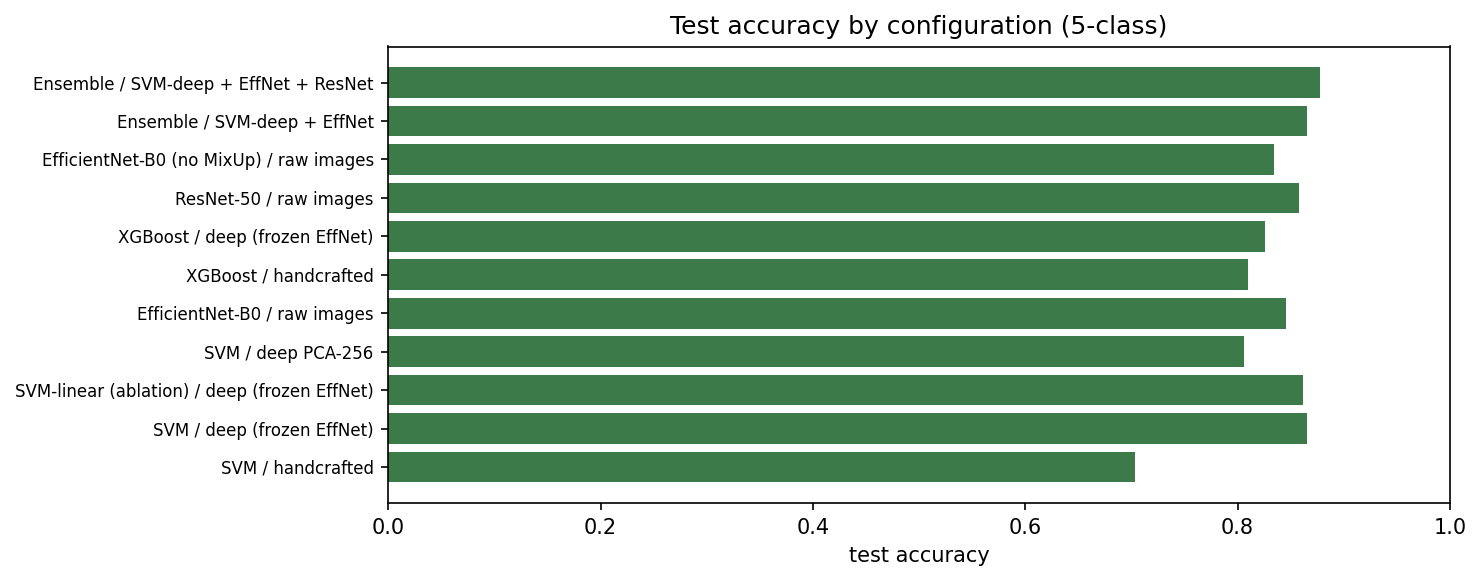

'/mnt/c/Users/Alecs/PML/Project_1/figures/final_accuracy_bars_nomix.png'

In [23]:
results_df = pd.DataFrame(results_rows())
results_df.to_csv(os.path.join(PATHS["results_dir"], "final_results_nomix.csv"), index=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
plot_df = results_df.dropna(subset=["test_acc"]).copy()
labels = plot_df["model"] + " / " + plot_df["features"]
ax.barh(range(len(plot_df)), plot_df["test_acc"], color="#3d7a4a")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("test accuracy")
ax.set_xlim(0, 1)
ax.set_title("Test accuracy by configuration (5-class)")
fig.tight_layout()
save_and_show(fig, "final_accuracy_bars_nomix.png", PATHS["figures_dir"])


## 13. Conclusions

- Same two representations and the same grading loop as the 6-class notebook, on Esgario's five-class label set (1,685 images).
- Official 6-class numbers remain in `P1_notebook.ipynb` / `results/final_results.csv`.
- Residual Mixed rule is not used (no class 5).
- Compare ResNet-50 / EfficientNet here to Esgario's 95.63% with the protocol caveats in section 12.


In [24]:
payload = {
    "n_csv": summary["n_csv"],
    "n_kept": summary["n_kept"],
    "drop_mixed": summary["drop_mixed"],
    "split": split.sizes(),
    "results": results_rows(),
}
with open(os.path.join(PATHS["results_dir"], "run_summary_nomix.json"), "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, default=str)
print("Wrote results/run_summary_nomix.json")


Wrote results/run_summary_nomix.json
